# 🎨 Generative AI Practical Handbook in Python

---

Welcome to the **Generative AI Practical Handbook** | a comprehensive, hands-on guide covering the theory and implementation of the most important generative modelling frameworks: **GANs**, **VAEs**, and **Diffusion Models**.

### 📚 Table of Contents
1. Introduction to Generative AI
2. Foundations | Probability & Latent Spaces
3. Autoencoders (Building Block)
4. Variational Autoencoders (VAEs)
5. VAE : Image Generation & Latent Space Exploration
6. Generative Adversarial Networks (GANs) : Theory
7. Vanilla GAN Implementation
8. Deep Convolutional GAN (DCGAN)
9. GAN Training Challenges & Solutions
10. Diffusion Models : Theory & Foundations
11. Denoising Diffusion : Implementation
12. Mini Project : Generative Model Comparison

---


In [1]:
!pip install torch torchvision numpy matplotlib seaborn scipy scikit-learn tqdm --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from scipy.stats import norm
import random

# Global reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device selection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Global plot style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})


---
## Section 1: Introduction to Generative AI

### What is Generative AI?

**Generative AI** refers to machine learning models that learn the underlying data distribution `p(x)` and can **sample new data points** from it generating new images, audio, text, or any structured data.

### Discriminative vs Generative Models

| | Discriminative | Generative |
|---|---|---|
| **Goal** | Learn `p(y|x)` | Learn `p(x)` or `p(x,y)` |
| **Task** | Classification, regression | Data synthesis, density estimation |
| **Examples** | CNN classifier, Logistic Regression | GAN, VAE, Diffusion, GPT |
| **Output** | Label/probability | New data sample |

### The Generative Model Zoo

```
Generative Models
├── Explicit Density (directly model p(x))
│   ├── Tractable   → Autoregressive (PixelCNN, GPT)
│   └── Approximate → VAE (variational inference)
│                   → Diffusion Models (denoising)
└── Implicit Density (sample without explicit p(x))
    └── GAN (adversarial game)
```

### Applications
| Domain | Applications |
|---|---|
| **Images** | Image synthesis, super-resolution, inpainting, style transfer |
| **Text** | Story generation, code generation, dialogue (GPT-4, Claude) |
| **Audio** | Music generation, voice cloning, text-to-speech |
| **Science** | Drug discovery (molecule generation), protein design |
| **Video** | Video generation, frame interpolation |
| **3D** | Point cloud generation, 3D shape synthesis |

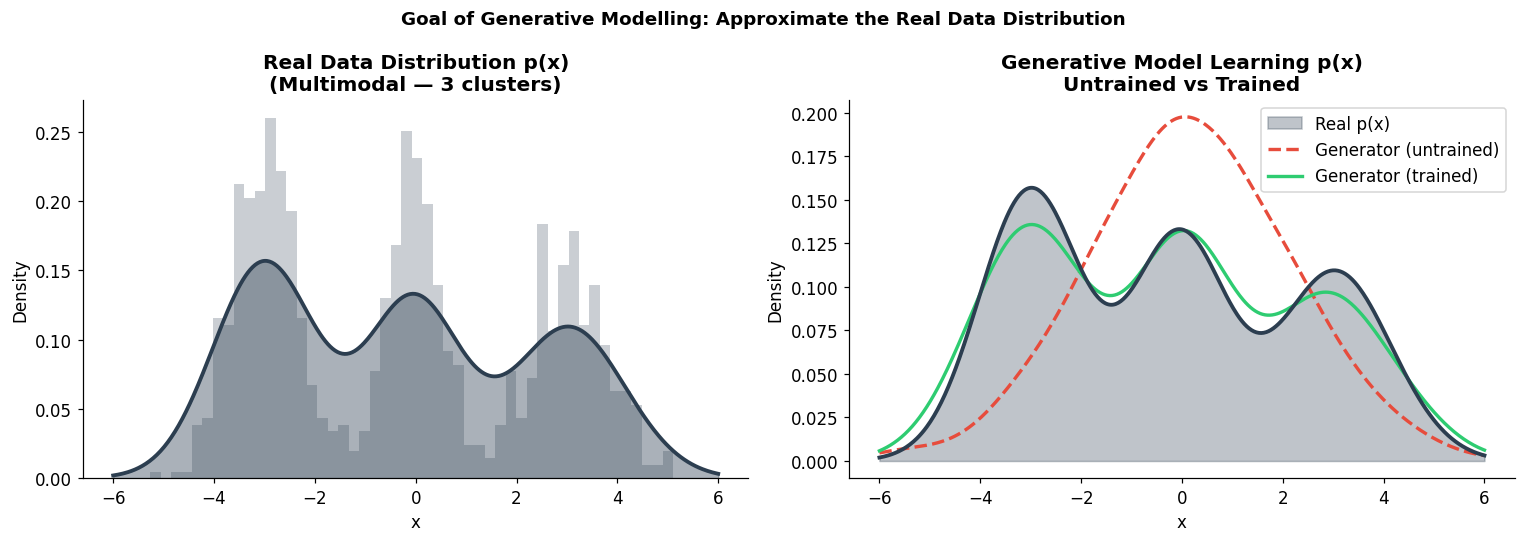

In [2]:

#  Visualise: what does 'learning a distribution' mean?

from scipy.stats import norm, gaussian_kde

np.random.seed(SEED)

# Simulate a complex multimodal real data distribution
real_data = np.concatenate([
    np.random.normal(-3, 0.7, 400),
    np.random.normal(0,  0.5, 300),
    np.random.normal(3,  0.8, 300)
])

# KDE to estimate p(x)
kde_real = gaussian_kde(real_data, bw_method=0.3)
x_range  = np.linspace(-6, 6, 500)

# Simulate early vs late generative model approximations
gen_early = np.random.normal(0, 2, 1000)          # poor early model
gen_late  = np.concatenate([                        # good trained model
    np.random.normal(-3, 0.9, 400),
    np.random.normal(0,  0.6, 300),
    np.random.normal(3,  1.0, 300)
])
kde_early = gaussian_kde(gen_early,  bw_method=0.3)
kde_late  = gaussian_kde(gen_late,   bw_method=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Real distribution
axes[0].fill_between(x_range, kde_real(x_range), alpha=0.4, color='#2c3e50', label='Real p(x)')
axes[0].plot(x_range, kde_real(x_range), color='#2c3e50', linewidth=2.5)
axes[0].hist(real_data, bins=50, density=True, alpha=0.25, color='#2c3e50')
axes[0].set_title('Real Data Distribution p(x)\n(Multimodal — 3 clusters)', fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')

# Right: Generator improving
axes[1].fill_between(x_range, kde_real(x_range),  alpha=0.3, color='#2c3e50', label='Real p(x)')
axes[1].plot(x_range, kde_early(x_range), color='#e74c3c', linewidth=2.2,
              linestyle='--', label='Generator (untrained)')
axes[1].plot(x_range, kde_late(x_range),  color='#2ecc71', linewidth=2.2,
              label='Generator (trained)')
axes[1].plot(x_range, kde_real(x_range),  color='#2c3e50', linewidth=2.5)
axes[1].set_title('Generative Model Learning p(x)\nUntrained vs Trained', fontweight='bold')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Goal of Generative Modelling: Approximate the Real Data Distribution',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



---
## Section 2: Foundations / Probability & Latent Spaces

### The Latent Space Concept

All modern generative models work with a **latent space** `Z` : a compressed, lower-dimensional representation of the data space `X`.

```
Data Space X             Latent Space Z
─────────────────        ──────────────────
High-dimensional         Low-dimensional
Entangled features       Disentangled factors
e.g. 784-dim image   →   e.g. 2-20 dim vector

    ENCODER: x → z   (compress)
    DECODER: z → x   (reconstruct / generate)
```

### Key Probability Concepts

| Concept | Formula | Role in Generative AI |
|---|---|---|
| **Prior** | `p(z)` | Distribution over latent codes (usually N(0,I)) |
| **Likelihood** | `p(x\|z)` | How well decoder reconstructs x from z |
| **Posterior** | `p(z\|x)` | Which latent code explains this data point? |
| **Evidence / Marginal** | `p(x) = ∫p(x\|z)p(z)dz` | True data distribution (intractable!) |
| **KL Divergence** | `KL(q \|\| p)` | Measures distance between two distributions |

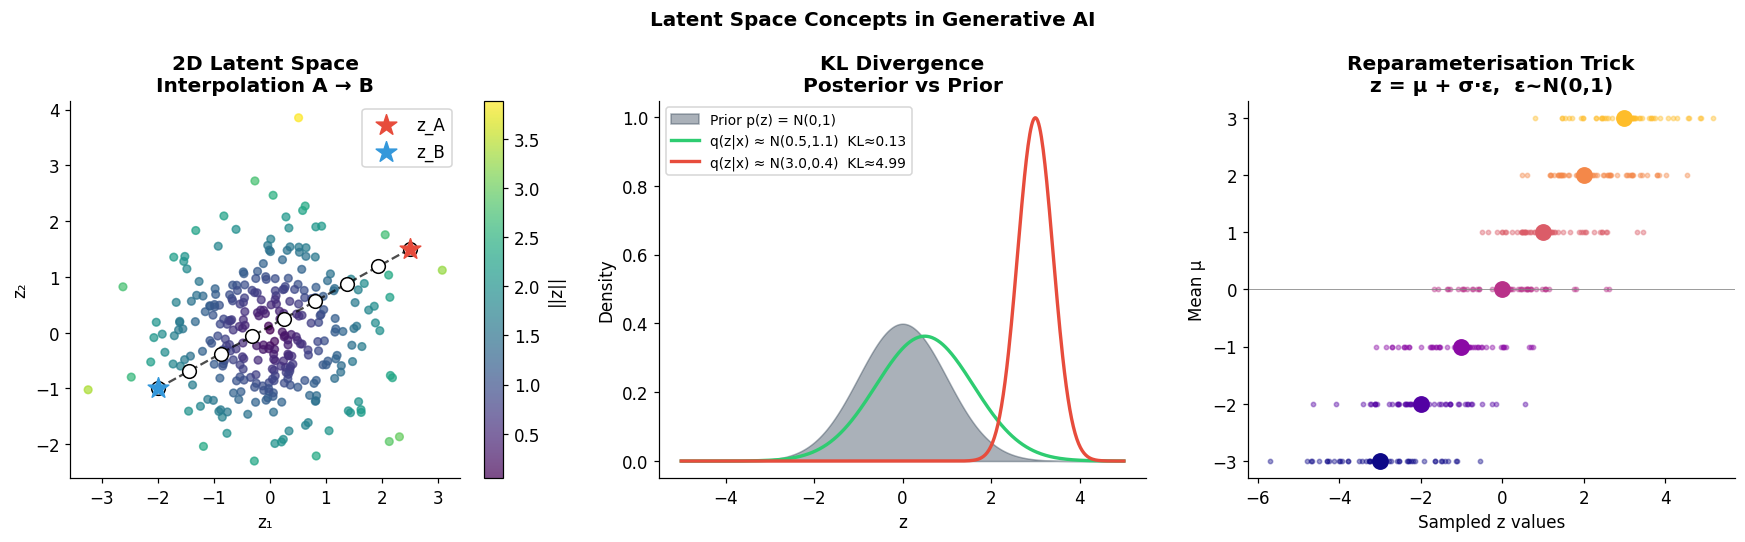

In [3]:
# Section 2 — Visualise Latent Space & KL Divergence

from scipy.stats import norm

# Latent space interpolation concept 
np.random.seed(SEED)
# Two 'concept' points in latent space
z_a = np.array([2.5,  1.5])
z_b = np.array([-2.0, -1.0])
alphas = np.linspace(0, 1, 9)
z_interp = [(1-a)*z_a + a*z_b for a in alphas]

# 2D latent space with some sample points
z_samples = np.random.randn(300, 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Latent space scatter
scatter = axes[0].scatter(z_samples[:,0], z_samples[:,1],
                           c=np.linalg.norm(z_samples, axis=1),
                           cmap='viridis', s=25, alpha=0.7)
axes[0].scatter(*z_a, color='#e74c3c', s=200, zorder=5, marker='*', label='z_A')
axes[0].scatter(*z_b, color='#3498db', s=200, zorder=5, marker='*', label='z_B')
zi = np.array(z_interp)
axes[0].plot(zi[:,0], zi[:,1], 'k--', linewidth=1.5, alpha=0.7)
axes[0].scatter(zi[:,0], zi[:,1], color='white', edgecolors='black', s=80, zorder=4)
plt.colorbar(scatter, ax=axes[0], label='||z||')
axes[0].set_title('2D Latent Space\nInterpolation A → B', fontweight='bold')
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')
axes[0].legend()

# KL Divergence: q(z|x) vs p(z)
x_vals = np.linspace(-5, 5, 500)
p_z    = norm.pdf(x_vals, 0, 1)         # Standard normal prior
q_good = norm.pdf(x_vals, 0.5, 1.1)     # Close to prior
q_bad  = norm.pdf(x_vals, 3.0, 0.4)     # Far from prior

kl_good = np.sum(q_good * np.log((q_good + 1e-10) / (p_z + 1e-10))) * 0.02
kl_bad  = np.sum(q_bad  * np.log((q_bad  + 1e-10) / (p_z + 1e-10))) * 0.02

axes[1].fill_between(x_vals, p_z,    alpha=0.4, color='#2c3e50', label=f'Prior p(z) = N(0,1)')
axes[1].plot(x_vals, q_good, color='#2ecc71', linewidth=2.2,
              label=f'q(z|x) ≈ N(0.5,1.1)  KL≈{kl_good:.2f}')
axes[1].plot(x_vals, q_bad,  color='#e74c3c', linewidth=2.2,
              label=f'q(z|x) ≈ N(3.0,0.4)  KL≈{kl_bad:.2f}')
axes[1].set_title('KL Divergence\nPosterior vs Prior', fontweight='bold')
axes[1].set_xlabel('z'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

# Reparameterisation trick
mu_vals    = np.linspace(-3, 3, 7)
log_var    = np.zeros(7)
eps        = np.random.randn(7, 50)
std        = np.exp(0.5 * log_var)
axes[2].axhline(0, color='gray', linewidth=0.5)
for i, mu in enumerate(mu_vals):
    z_reparam = mu + std[i] * eps[i]
    axes[2].scatter(z_reparam, np.full(50, mu), s=8, alpha=0.4,
                     color=plt.cm.plasma(i/7))
    axes[2].scatter(mu, mu, s=100, color=plt.cm.plasma(i/7), zorder=5)
axes[2].set_title('Reparameterisation Trick\nz = μ + σ·ε,  ε~N(0,1)', fontweight='bold')
axes[2].set_xlabel('Sampled z values')
axes[2].set_ylabel('Mean μ')

plt.suptitle('Latent Space Concepts in Generative AI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3: Autoencoders | The Building Block

Before VAEs and GANs, the **Autoencoder** is the foundational architecture for learning compressed data representations.

### Architecture
```
Input x  →  [Encoder]  →  z (bottleneck)  →  [Decoder]  →  x̂ (reconstruction)
  784-d        ↓               32-d                ↓             784-d
           Compress          Latent code         Generate
```

### Loss
```
L = ||x - x̂||²   (reconstruction loss — MSE or BCE)
```

### Limitation
A standard autoencoder has **no structured latent space**  you cannot sample new points from it meaningfully. The VAE fixes this.

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 439kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.06MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.21MB/s]


 MNIST loaded: 60000 train / 10000 test
   Image shape: 1×28×28 = 784 pixels
   Classes: digits 0-9


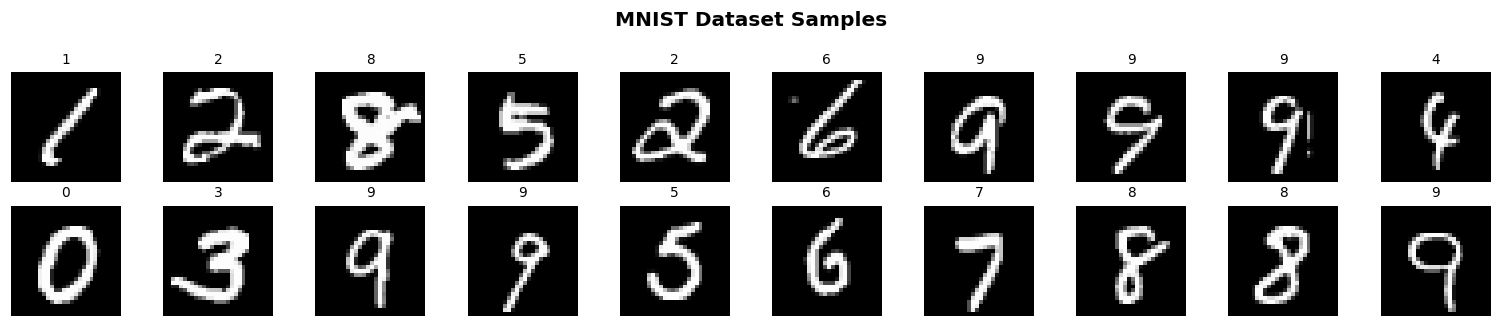

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=0)

print(f' MNIST loaded: {len(train_dataset)} train / {len(test_dataset)} test')
print(f'   Image shape: 1×28×28 = 784 pixels')
print(f'   Classes: digits 0-9')


images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(20):
    ax = axes[i//10, i%10]
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(str(labels[i].item()), fontsize=9)
    ax.axis('off')
plt.suptitle('MNIST Dataset Samples', fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),  nn.ReLU(),
            nn.Linear(512, 256),  nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 784),        nn.Tanh()
        )

    def encode(self, x):
        return self.encoder(x.view(-1, 784))

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        z    = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z



LATENT_DIM_AE = 32
ae_model   = Autoencoder(latent_dim=LATENT_DIM_AE).to(DEVICE)
ae_optim   = optim.Adam(ae_model.parameters(), lr=1e-3)
AE_EPOCHS  = 10
ae_losses  = []

print(f' Autoencoder: {sum(p.numel() for p in ae_model.parameters()):,} parameters')
print(f'   Bottleneck: 784 → {LATENT_DIM_AE} ({LATENT_DIM_AE/784*100:.1f}% compression)\n')

ae_model.train()
for epoch in range(AE_EPOCHS):
    epoch_loss = 0
    for imgs, _ in train_loader:
        imgs   = imgs.to(DEVICE)
        x_hat, _ = ae_model(imgs)
        loss   = F.mse_loss(x_hat, imgs)
        ae_optim.zero_grad()
        loss.backward()
        ae_optim.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    ae_losses.append(avg)
    print(f'  Epoch {epoch+1:2d}/{AE_EPOCHS}  MSE Loss: {avg:.5f}')

 Autoencoder: 1,083,696 parameters
   Bottleneck: 784 → 32 (4.1% compression)

  Epoch  1/10  MSE Loss: 0.12905
  Epoch  2/10  MSE Loss: 0.05438
  Epoch  3/10  MSE Loss: 0.04270
  Epoch  4/10  MSE Loss: 0.03604
  Epoch  5/10  MSE Loss: 0.03207
  Epoch  6/10  MSE Loss: 0.02941
  Epoch  7/10  MSE Loss: 0.02743
  Epoch  8/10  MSE Loss: 0.02588
  Epoch  9/10  MSE Loss: 0.02478
  Epoch 10/10  MSE Loss: 0.02370


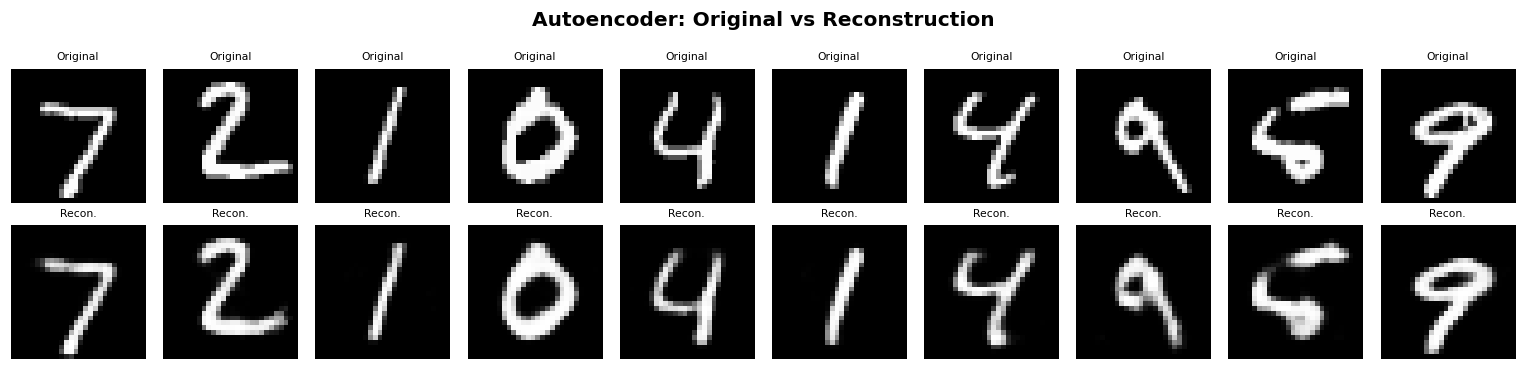

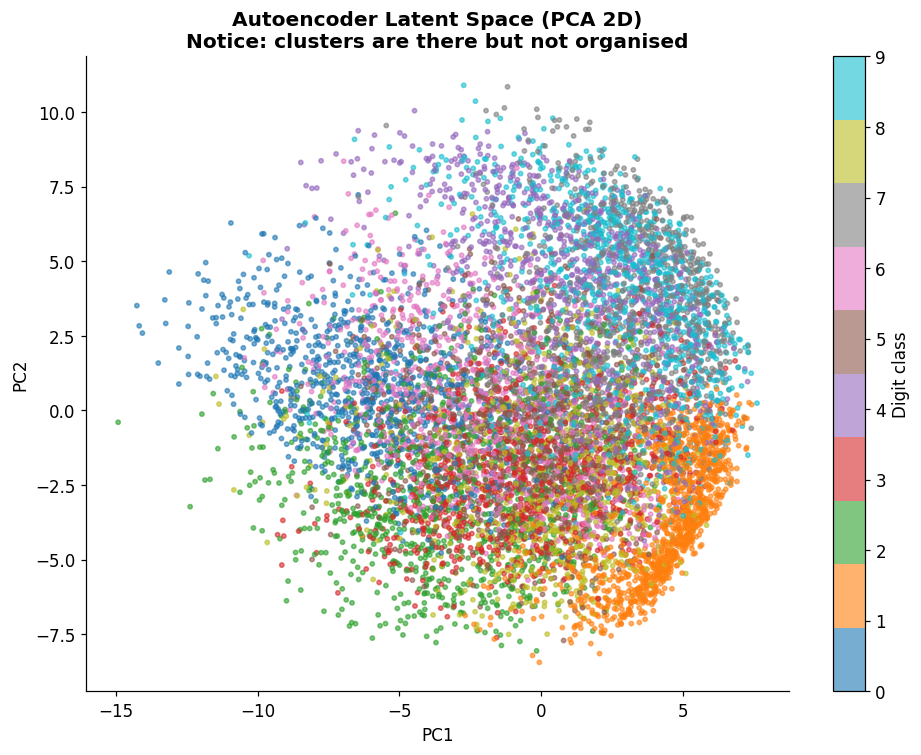

In [6]:

ae_model.eval()
test_imgs, test_labels = next(iter(test_loader))
test_imgs = test_imgs[:10].to(DEVICE)

with torch.no_grad():
    recons, latent_codes = ae_model(test_imgs)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for i in range(10):
    axes[0, i].imshow(test_imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title('Original', fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(recons[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title('Recon.', fontsize=7)
    axes[1, i].axis('off')

plt.suptitle('Autoencoder: Original vs Reconstruction', fontweight='bold')
plt.tight_layout()
plt.show()


from sklearn.decomposition import PCA

all_latents, all_labels = [], []
ae_model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        _, z = ae_model(imgs.to(DEVICE))
        all_latents.append(z.cpu().numpy())
        all_labels.append(lbls.numpy())

Z_all  = np.concatenate(all_latents)
L_all  = np.concatenate(all_labels)
Z_2d   = PCA(n_components=2).fit_transform(Z_all)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(Z_2d[:,0], Z_2d[:,1], c=L_all, cmap='tab10', s=8, alpha=0.6)
plt.colorbar(scatter, ax=ax, label='Digit class', ticks=range(10))
ax.set_title('Autoencoder Latent Space (PCA 2D)\n'
              'Notice: clusters are there but not organised', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()


---
## Section 4: Variational Autoencoders (VAEs)

The **VAE** (Kingma & Welling, 2013) solves the sampling problem by imposing a **structured prior** on the latent space.

### Key Idea
Instead of encoding `x → z` (deterministic), encode `x → p(z|x) = N(μ, σ²)` (probabilistic).

### ELBO | Evidence Lower Bound
VAEs maximise the **ELBO** (a tractable lower bound of log p(x)):
```
ELBO = E[log p(x|z)]  −  KL(q(z|x) || p(z))
       └─────────────┘   └──────────────────┘
       Reconstruction     Regularisation term
       (how well x is     (push posterior toward
        reconstructed)      standard normal prior)
```

### The Reparameterisation Trick
Sampling `z ~ N(μ, σ²)` is not differentiable. Solution:
```
z = μ + σ · ε,   ε ~ N(0, I)
     ↑   ↑
  learned  reparameterised noise (gradient flows through μ and σ!)
```

### KL Divergence (Closed Form for Gaussians)
```
KL(N(μ,σ²) || N(0,1)) = -½ · Σ(1 + log σ² - μ² - σ²)
```

In [7]:
class VAE(nn.Module):
    """
    Variational Autoencoder with:
    - Encoder:  x → (μ, log_var) of q(z|x)
    - Reparameterisation: z = μ + σ·ε
    - Decoder:  z → p(x|z)
    """
    def __init__(self, input_dim=784, latent_dim=20, hidden_dim=512):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: x → shared features → (μ, log σ²)
        self.encoder_shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU()
        )
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)   # mean
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)   # log variance

        # Decoder: z → x̂
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),  nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),   nn.Sigmoid()
        )

    def encode(self, x):
        """Returns μ and log σ² for q(z|x)."""
        h       = self.encoder_shared(x.view(-1, 784))
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    def reparameterise(self, mu, log_var):
        """z = μ + σ·ε  — differentiable sampling."""
        if self.training:
            std = torch.exp(0.5 * log_var)   # σ = exp(log σ² / 2)
            eps = torch.randn_like(std)       # ε ~ N(0,I)
            return mu + std * eps
        return mu   # deterministic at inference

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z           = self.reparameterise(mu, log_var)
        x_recon     = self.decode(z)
        return x_recon, mu, log_var


def vae_loss(x_recon, x_original, mu, log_var, beta=1.0):
    """
    Total VAE loss = Reconstruction loss + β·KL divergence
    β > 1 → β-VAE (more disentangled latent space)
    """
    # Reconstruction: Binary Cross-Entropy per pixel
    # Normalise input to [0,1] for BCE
    x_01     = (x_original * 0.5 + 0.5)   # [-1,1] → [0,1]
    recon_loss = F.binary_cross_entropy(
        x_recon.view(-1, 784),
        x_01.view(-1, 784),
        reduction='sum'
    )
    # KL divergence (closed form): -½ Σ(1 + log σ² - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return (recon_loss + beta * kl_loss) / x_original.size(0)


LATENT_DIM_VAE = 2     # 2D for easy visualisation!
BETA           = 1.0
VAE_EPOCHS     = 15

vae_model  = VAE(latent_dim=LATENT_DIM_VAE).to(DEVICE)
vae_optim  = optim.Adam(vae_model.parameters(), lr=1e-3)
vae_scheduler = optim.lr_scheduler.StepLR(vae_optim, step_size=5, gamma=0.7)

total_p = sum(p.numel() for p in vae_model.parameters())
print(f' VAE: {total_p:,} parameters | Latent dim: {LATENT_DIM_VAE} | β={BETA}')


transform_01 = transforms.Compose([transforms.ToTensor()])
vae_train_ds  = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform_01)
vae_test_ds   = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform_01)
vae_train_loader = DataLoader(vae_train_ds, batch_size=128, shuffle=True,  num_workers=0)
vae_test_loader  = DataLoader(vae_test_ds,  batch_size=256, shuffle=False, num_workers=0)

vae_train_losses = []
vae_recon_losses = []
vae_kl_losses    = []

print()
for epoch in range(VAE_EPOCHS):
    vae_model.train()
    epoch_loss = epoch_recon = epoch_kl = 0
    for imgs, _ in vae_train_loader:
        imgs        = imgs.to(DEVICE)
        x_recon, mu, log_var = vae_model(imgs)
        recon_term  = F.binary_cross_entropy(
            x_recon.view(-1,784), imgs.view(-1,784), reduction='sum'
        ) / imgs.size(0)
        kl_term     = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / imgs.size(0)
        loss        = recon_term + BETA * kl_term
        vae_optim.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vae_model.parameters(), 1.0)
        vae_optim.step()
        epoch_loss  += loss.item()
        epoch_recon += recon_term.item()
        epoch_kl    += kl_term.item()

    vae_scheduler.step()
    n = len(vae_train_loader)
    vae_train_losses.append(epoch_loss/n)
    vae_recon_losses.append(epoch_recon/n)
    vae_kl_losses.append(epoch_kl/n)
    print(f'  Epoch {epoch+1:2d}/{VAE_EPOCHS}  '
          f'Total: {epoch_loss/n:.2f}  '
          f'Recon: {epoch_recon/n:.2f}  '
          f'KL: {epoch_kl/n:.2f}')

 VAE: 1,333,012 parameters | Latent dim: 2 | β=1.0

  Epoch  1/15  Total: 176.29  Recon: 171.73  KL: 4.56
  Epoch  2/15  Total: 156.71  Recon: 151.12  KL: 5.59
  Epoch  3/15  Total: 151.66  Recon: 145.78  KL: 5.89
  Epoch  4/15  Total: 148.91  Recon: 142.86  KL: 6.06
  Epoch  5/15  Total: 147.04  Recon: 140.85  KL: 6.20
  Epoch  6/15  Total: 145.15  Recon: 138.89  KL: 6.26
  Epoch  7/15  Total: 144.28  Recon: 137.95  KL: 6.33
  Epoch  8/15  Total: 143.66  Recon: 137.28  KL: 6.37
  Epoch  9/15  Total: 142.92  Recon: 136.51  KL: 6.42
  Epoch 10/15  Total: 142.78  Recon: 136.34  KL: 6.43
  Epoch 11/15  Total: 141.63  Recon: 135.15  KL: 6.48
  Epoch 12/15  Total: 141.03  Recon: 134.51  KL: 6.53
  Epoch 13/15  Total: 140.61  Recon: 134.06  KL: 6.56
  Epoch 14/15  Total: 140.07  Recon: 133.49  KL: 6.58
  Epoch 15/15  Total: 139.77  Recon: 133.16  KL: 6.60


---
## Section 5: VAE | Image Generation & Latent Space Exploration

Now the VAE is trained, we can:
1. **Reconstruct** existing images
2. **Generate new images** by sampling `z ~ N(0,I)` and decoding
3. **Interpolate** between two images in latent space
4. **Explore** the 2D latent space systematically
5. Visualise the **structured latent manifold**

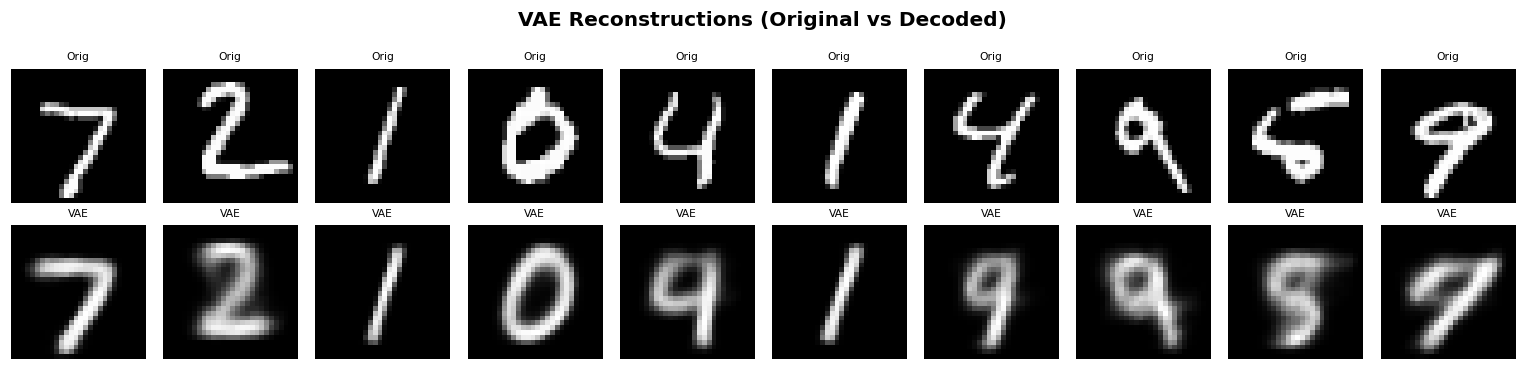

In [8]:
vae_model.eval()

test_imgs_vae, test_labels_vae = next(iter(vae_test_loader))
test_imgs_vae = test_imgs_vae[:10].to(DEVICE)

with torch.no_grad():
    recons_vae, mu_test, _ = vae_model(test_imgs_vae)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for i in range(10):
    axes[0,i].imshow(test_imgs_vae[i].cpu().squeeze(), cmap='gray')
    axes[0,i].set_title('Orig', fontsize=7); axes[0,i].axis('off')
    axes[1,i].imshow(recons_vae[i].cpu().squeeze(), cmap='gray')
    axes[1,i].set_title('VAE', fontsize=7); axes[1,i].axis('off')

plt.suptitle('VAE Reconstructions (Original vs Decoded)', fontweight='bold')
plt.tight_layout()
plt.show()

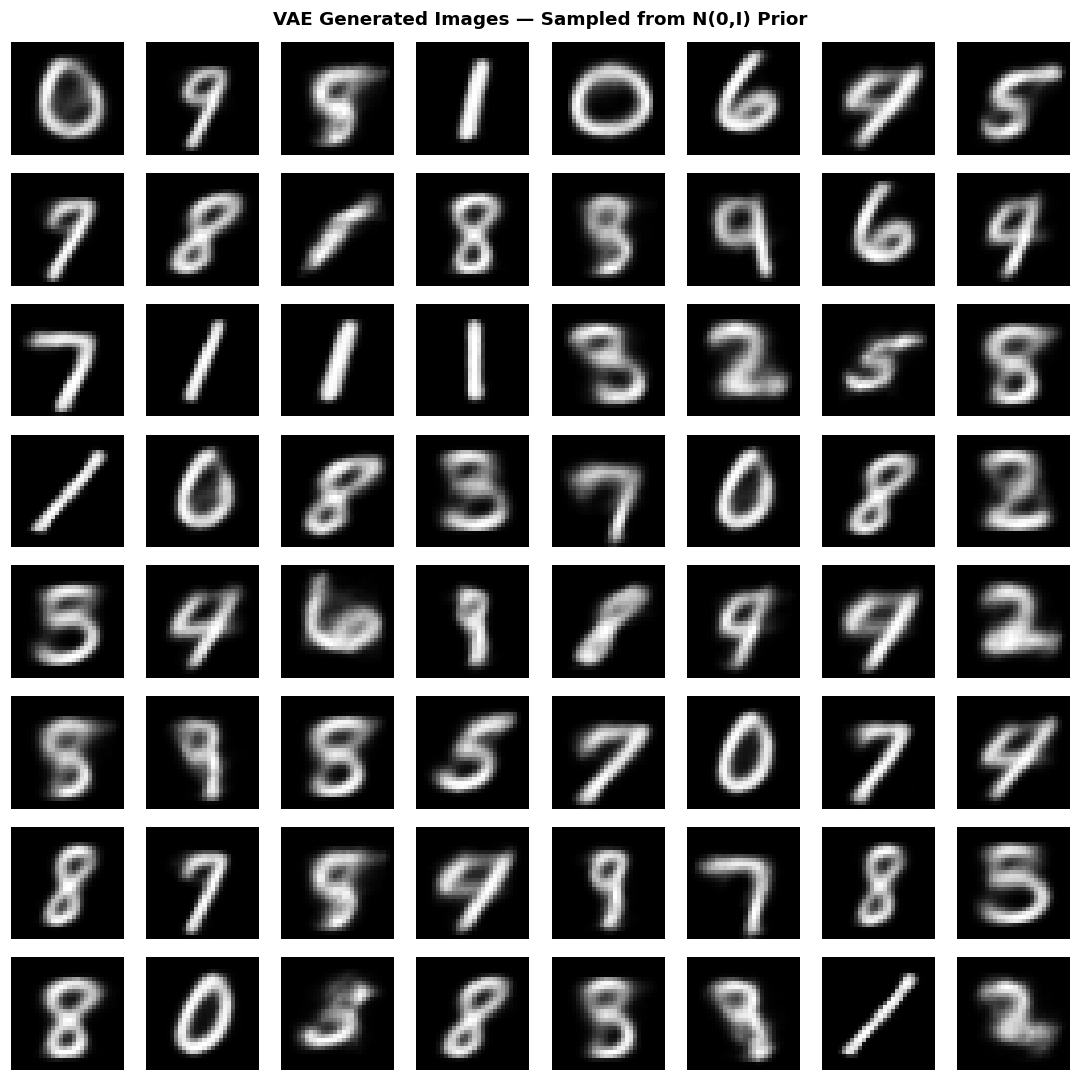

In [9]:
with torch.no_grad():
    z_random = torch.randn(64, LATENT_DIM_VAE).to(DEVICE)  # sample from prior
    generated = vae_model.decode(z_random)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('VAE Generated Images — Sampled from N(0,I) Prior', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

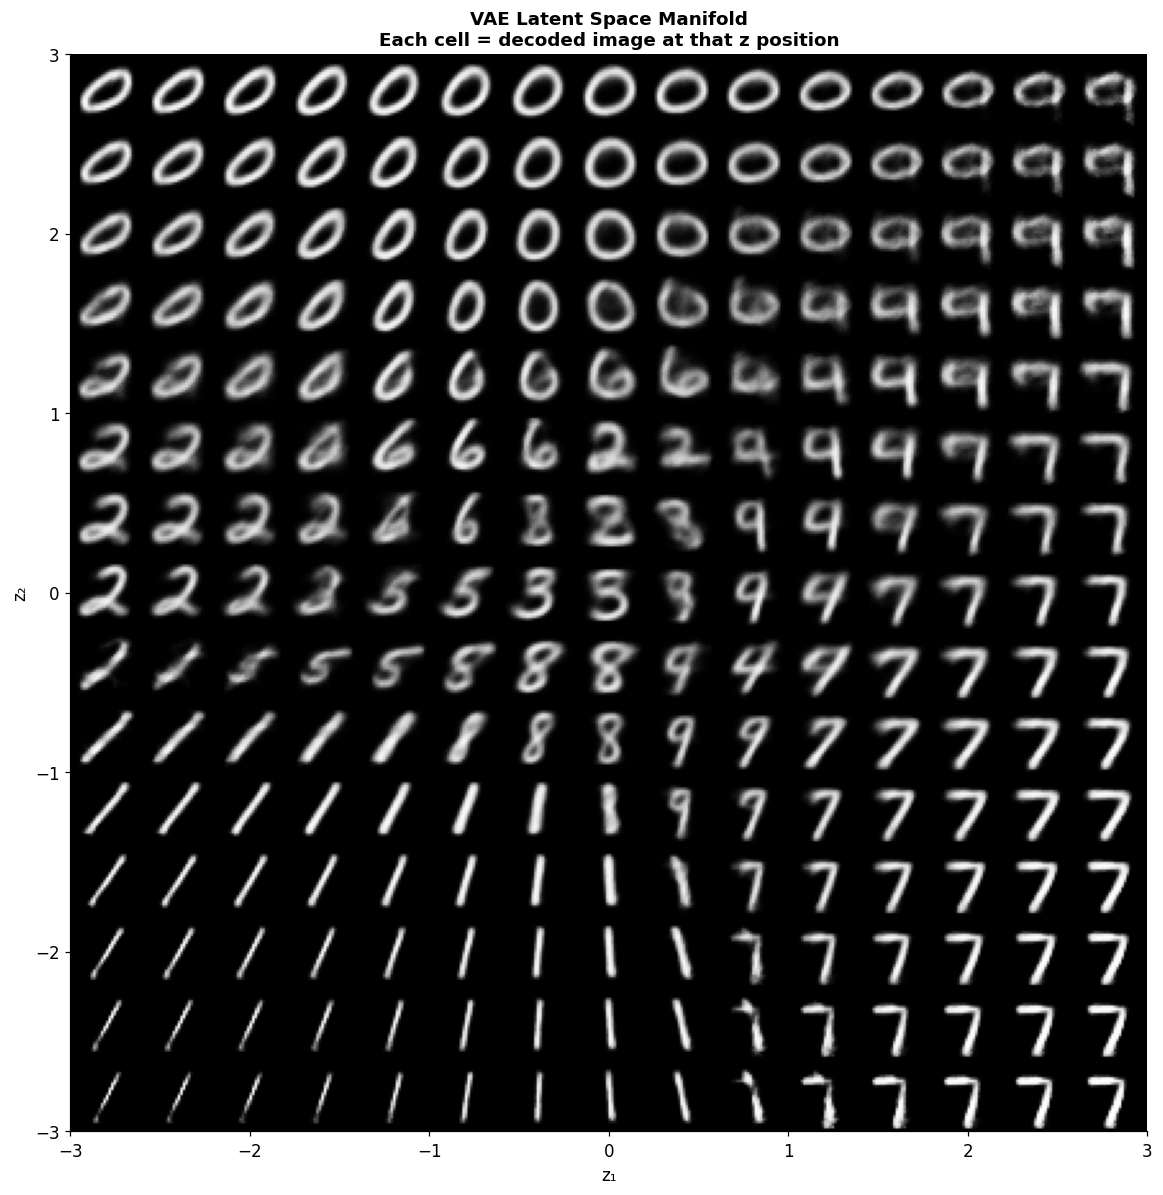

In [10]:
n_grid   = 15
z_range  = np.linspace(-3, 3, n_grid)

canvas   = np.zeros((28 * n_grid, 28 * n_grid))

with torch.no_grad():
    for i, zi in enumerate(z_range):
        for j, zj in enumerate(z_range):
            z_pt  = torch.tensor([[zj, zi]], dtype=torch.float32).to(DEVICE)
            img   = vae_model.decode(z_pt)
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img[0,0].cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(canvas, cmap='gray', origin='upper',
           extent=[-3, 3, -3, 3])
ax.set_title('VAE Latent Space Manifold\n'
              'Each cell = decoded image at that z position',
              fontweight='bold', fontsize=12)
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.grid(False)
plt.tight_layout()
plt.show()

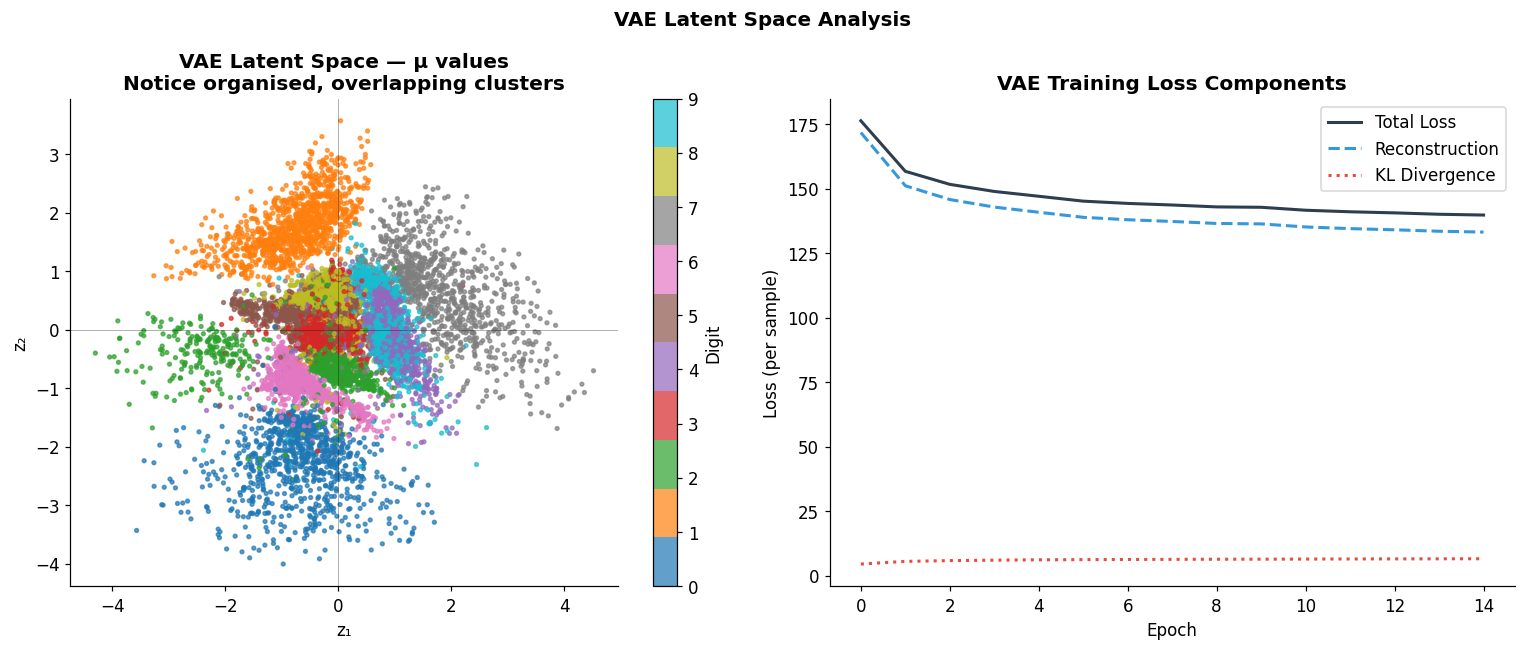

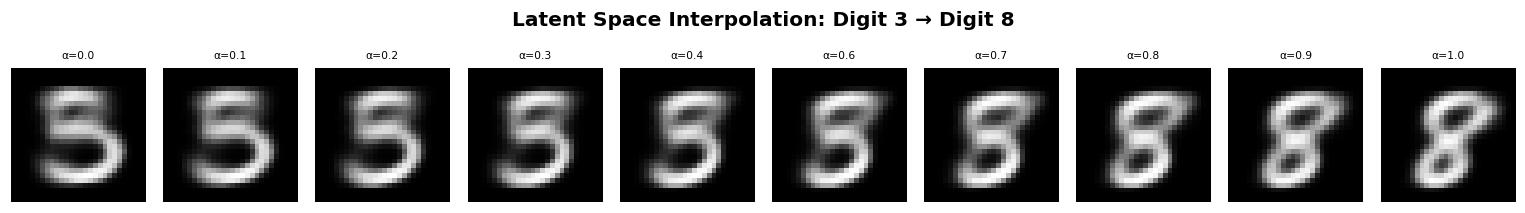

In [11]:
# 4. Latent Space: Coloured by Digit Class 
all_mu, all_lbl = [], []
vae_model.eval()
with torch.no_grad():
    for imgs, lbls in vae_test_loader:
        mu_b, _ = vae_model.encode(imgs.to(DEVICE))
        all_mu.append(mu_b.cpu().numpy())
        all_lbl.append(lbls.numpy())

Z_mu  = np.concatenate(all_mu)
L_mu  = np.concatenate(all_lbl)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc = axes[0].scatter(Z_mu[:,0], Z_mu[:,1], c=L_mu, cmap='tab10',
                      s=6, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='Digit', ticks=range(10))
axes[0].set_title('VAE Latent Space — μ values\n'
                   'Notice organised, overlapping clusters', fontweight='bold')
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')
axes[0].axhline(0, color='black', linewidth=0.5, alpha=0.4)
axes[0].axvline(0, color='black', linewidth=0.5, alpha=0.4)

# Loss curves
axes[1].plot(vae_train_losses, color='#2c3e50', linewidth=2, label='Total Loss')
axes[1].plot(vae_recon_losses, color='#3498db', linewidth=2, linestyle='--', label='Reconstruction')
axes[1].plot(vae_kl_losses,    color='#e74c3c', linewidth=2, linestyle=':',  label='KL Divergence')
axes[1].set_title('VAE Training Loss Components', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (per sample)')
axes[1].legend()

plt.suptitle('VAE Latent Space Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#  5. Latent space interpolation between two digits 
def get_digit_encoding(digit_class, n=5):
    imgs = [img for img, lbl in vae_test_ds if lbl == digit_class][:n]
    batch = torch.stack(imgs).to(DEVICE)
    with torch.no_grad():
        mu, _ = vae_model.encode(batch)
    return mu.mean(0)   # average encoding

z_digit3 = get_digit_encoding(3)
z_digit8 = get_digit_encoding(8)
n_steps  = 10
alphas   = torch.linspace(0, 1, n_steps)

fig, axes = plt.subplots(1, n_steps, figsize=(14, 2))
with torch.no_grad():
    for i, alpha in enumerate(alphas):
        z_interp = (1 - alpha) * z_digit3 + alpha * z_digit8
        img = vae_model.decode(z_interp.unsqueeze(0))
        axes[i].imshow(img[0,0].cpu().numpy(), cmap='gray')
        axes[i].set_title(f'α={alpha:.1f}', fontsize=7)
        axes[i].axis('off')

plt.suptitle('Latent Space Interpolation: Digit 3 → Digit 8', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6: Generative Adversarial Networks (GANs) | Theory

**GANs** (Goodfellow et al., 2014) train two networks in an adversarial game:

### The Adversarial Game
```
                  z ~ N(0,I)
                      ↓
                 ┌─────────────┐
                 │  GENERATOR  │  G(z) = x̂  (fake image)
                 └─────────────┘
                       ↓
      Real x  →  ┌────────────────┐
                 │ DISCRIMINATOR  │  D(x) ∈ [0,1]  (real or fake?)
      Fake x̂  → └────────────────┘
```

### Minimax Objective
```
min_G max_D  V(G, D) = E[log D(x)] + E[log(1 − D(G(z)))]
              ↑                ↑
         Discriminator    Generator wants D to
         wants to be       be fooled (output ≈ 1)
         correct (1=real, 0=fake)
```

### Training Algorithm
```
For each iteration:
   Step 1: Update Discriminator (k steps) 
  Sample real batch x ~ p_data(x)
  Sample noise z ~ p_z(z), generate fake x̂ = G(z)
  Maximize:  log D(x) + log(1 - D(G(z)))

   Step 2: Update Generator (1 step) 
  Sample noise z ~ p_z(z)
  Minimize:  log(1 - D(G(z)))   [or equivalently, maximize log D(G(z))]
```

### GAN Evolution Timeline
| Year | Model | Innovation |
|---|---|---|
| 2014 | Vanilla GAN | Original adversarial framework |
| 2015 | DCGAN | Convolutional architecture, BatchNorm |
| 2017 | WGAN | Wasserstein distance, stable training |
| 2018 | StyleGAN | Style-based generator, progressive growing |
| 2019 | BigGAN | Large-scale class-conditional generation |
| 2021 | StyleGAN3 | Alias-free generation |

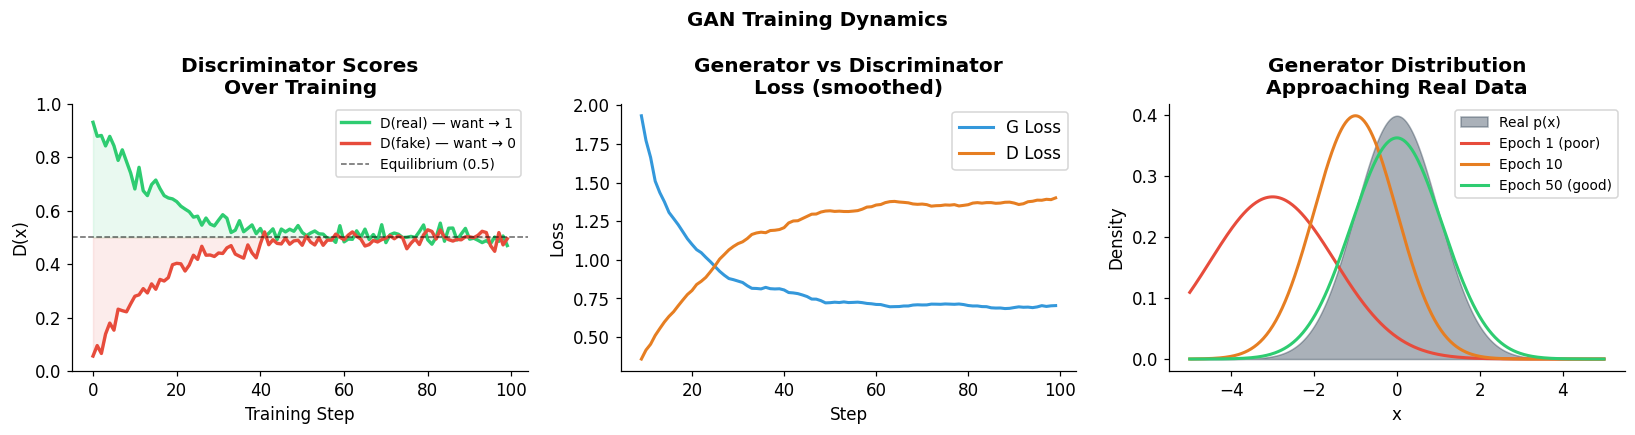

In [13]:
# Section 6 — Visualise GAN Minimax & Discriminator Behaviour

import matplotlib.patches as FancyArrow
import pandas as pd
# Simulate discriminator confidence during training
epochs_sim = np.arange(0, 100)
d_real     = 0.5 + 0.45 * np.exp(-epochs_sim / 15) + 0.02 * np.random.randn(100)
d_fake     = 0.5 - 0.45 * np.exp(-epochs_sim / 15) + 0.02 * np.random.randn(100)
d_fake     = np.clip(d_fake, 0.05, 0.95)
d_real     = np.clip(d_real, 0.05, 0.95)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Discriminator scores over training
axes[0].plot(d_real, color='#2ecc71', linewidth=2.2, label='D(real) — want → 1')
axes[0].plot(d_fake, color='#e74c3c', linewidth=2.2, label='D(fake) — want → 0')
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Equilibrium (0.5)')
axes[0].fill_between(epochs_sim, d_real, 0.5, alpha=0.1, color='#2ecc71')
axes[0].fill_between(epochs_sim, 0.5, d_fake, alpha=0.1, color='#e74c3c')
axes[0].set_ylim(0, 1)
axes[0].set_title('Discriminator Scores\nOver Training', fontweight='bold')
axes[0].set_xlabel('Training Step'); axes[0].set_ylabel('D(x)')
axes[0].legend(fontsize=9)

# Generator & Discriminator losses
g_loss = -np.log(d_fake + 1e-10)   # -log D(G(z))
d_loss = -np.log(d_real) - np.log(1 - d_fake + 1e-10)
axes[1].plot(pd.Series(g_loss).rolling(10).mean(), color='#3498db', linewidth=2, label='G Loss')
axes[1].plot(pd.Series(d_loss).rolling(10).mean(), color='#e67e22', linewidth=2, label='D Loss')
axes[1].set_title('Generator vs Discriminator\nLoss (smoothed)', fontweight='bold')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Loss')
axes[1].legend()

# Distribution shift: Generator improving
x_show = np.linspace(-5, 5, 400)
p_real = norm.pdf(x_show, 0, 1)
stages = [
    (norm.pdf(x_show, -3, 1.5), '#e74c3c', 'Epoch 1 (poor)'),
    (norm.pdf(x_show, -1, 1.0), '#e67e22', 'Epoch 10'),
    (norm.pdf(x_show,  0, 1.1), '#2ecc71', 'Epoch 50 (good)'),
]
axes[2].fill_between(x_show, p_real, alpha=0.4, color='#2c3e50', label='Real p(x)')
for pdf, color, label in stages:
    axes[2].plot(x_show, pdf, color=color, linewidth=2, label=label)
axes[2].set_title('Generator Distribution\nApproaching Real Data', fontweight='bold')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=9)


plt.suptitle('GAN Training Dynamics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 7: Vanilla GAN Implementation

We implement a **fully-connected GAN** on MNIST — the "Hello World" of GANs.

### Architecture
```
Generator G:
  z (100-d noise) → FC(256) → LeakyReLU → FC(512) → LeakyReLU
                             → FC(1024) → LeakyReLU → FC(784) → Tanh

Discriminator D:
  x (784-d image) → FC(1024) → LeakyReLU → Dropout → FC(512) → LeakyReLU
                              → Dropout  → FC(256) → LeakyReLU → FC(1) → Sigmoid
```

In [14]:
# Section 7 — Vanilla GAN on MNIST


# Generator 
class Generator(nn.Module):
    """Maps noise z → fake image."""
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, 784),
            nn.Tanh()     # output in [-1, 1]
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


#  Discriminator 
class Discriminator(nn.Module):
    """Maps image → probability of being real."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2),    # LeakyReLU prevents dead neurons
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()     # P(real)
        )

    def forward(self, x):
        return self.net(x.view(-1, 784))


#  Initialise networks 
LATENT_DIM_GAN = 100
G = Generator(latent_dim=LATENT_DIM_GAN).to(DEVICE)
D = Discriminator().to(DEVICE)

# Use normal init for weights (helps GAN training)
def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

G.apply(weights_init)
D.apply(weights_init)

g_optim = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_optim = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()

g_params = sum(p.numel() for p in G.parameters())
d_params = sum(p.numel() for p in D.parameters())
print(f' Vanilla GAN')
print(f'   Generator:     {g_params:,} parameters')
print(f'   Discriminator: {d_params:,} parameters')

 Vanilla GAN
   Generator:     1,489,936 parameters
   Discriminator: 1,460,225 parameters


In [15]:
#  GAN Training Loop 
# Use the [-1,1] normalised MNIST loader
GAN_EPOCHS  = 30
gan_g_losses = []
gan_d_losses = []
gan_d_real   = []
gan_d_fake   = []

# Fixed noise for consistent sample visualisation
fixed_noise = torch.randn(64, LATENT_DIM_GAN).to(DEVICE)
sample_snapshots = {}   # store generated images at specific epochs



for epoch in range(GAN_EPOCHS):
    g_loss_ep = d_loss_ep = d_r_ep = d_f_ep = 0
    n_batches = 0

    G.train(); D.train()

    for real_imgs, _ in train_loader:
        B          = real_imgs.size(0)
        real_imgs  = real_imgs.to(DEVICE)

        # ── Labels ──
        real_labels = torch.ones(B,  1).to(DEVICE) * 0.9  # label smoothing
        fake_labels = torch.zeros(B, 1).to(DEVICE)

     
        # step 1: train discriminator
        
        d_optim.zero_grad()

        # Real images
        d_real_out = D(real_imgs)
        d_loss_real = criterion(d_real_out, real_labels)

        # Fake images
        z         = torch.randn(B, LATENT_DIM_GAN).to(DEVICE)
        fake_imgs = G(z).detach()   # detach — don't update G here
        d_fake_out = D(fake_imgs)
        d_loss_fake = criterion(d_fake_out, fake_labels)

        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        d_optim.step()

       
        # Step 2: Train Generator
      
        g_optim.zero_grad()

        z         = torch.randn(B, LATENT_DIM_GAN).to(DEVICE)
        fake_imgs = G(z)
        g_out     = D(fake_imgs)
        # Generator wants D to output 1 (think fake is real)
        g_loss    = criterion(g_out, torch.ones(B, 1).to(DEVICE))
        g_loss.backward()
        g_optim.step()

        g_loss_ep += g_loss.item()
        d_loss_ep += d_loss.item()
        d_r_ep    += d_real_out.mean().item()
        d_f_ep    += d_fake_out.mean().item()
        n_batches += 1

    # Log per epoch
    gan_g_losses.append(g_loss_ep / n_batches)
    gan_d_losses.append(d_loss_ep / n_batches)
    gan_d_real.append(d_r_ep / n_batches)
    gan_d_fake.append(d_f_ep / n_batches)

    # Save snapshots at key epochs
    if epoch + 1 in [1, 5, 10, 20, 30]:
        G.eval()
        with torch.no_grad():
            snaps = G(fixed_noise[:16]).cpu()
        sample_snapshots[epoch+1] = snaps
        G.train()

    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:2d}/{GAN_EPOCHS} | '
              f'G: {g_loss_ep/n_batches:.4f} | '
              f'D: {d_loss_ep/n_batches:.4f} | '
              f'D(real): {d_r_ep/n_batches:.3f} | '
              f'D(fake): {d_f_ep/n_batches:.3f}')



  Epoch  5/30 | G: 1.5524 | D: 0.5296 | D(real): 0.609 | D(fake): 0.294
  Epoch 10/30 | G: 1.0005 | D: 0.6413 | D(real): 0.502 | D(fake): 0.401
  Epoch 15/30 | G: 0.9263 | D: 0.6593 | D(real): 0.483 | D(fake): 0.420
  Epoch 20/30 | G: 0.8960 | D: 0.6649 | D(real): 0.477 | D(fake): 0.426
  Epoch 25/30 | G: 0.8858 | D: 0.6684 | D(real): 0.473 | D(fake): 0.429
  Epoch 30/30 | G: 0.8802 | D: 0.6692 | D(real): 0.472 | D(fake): 0.430


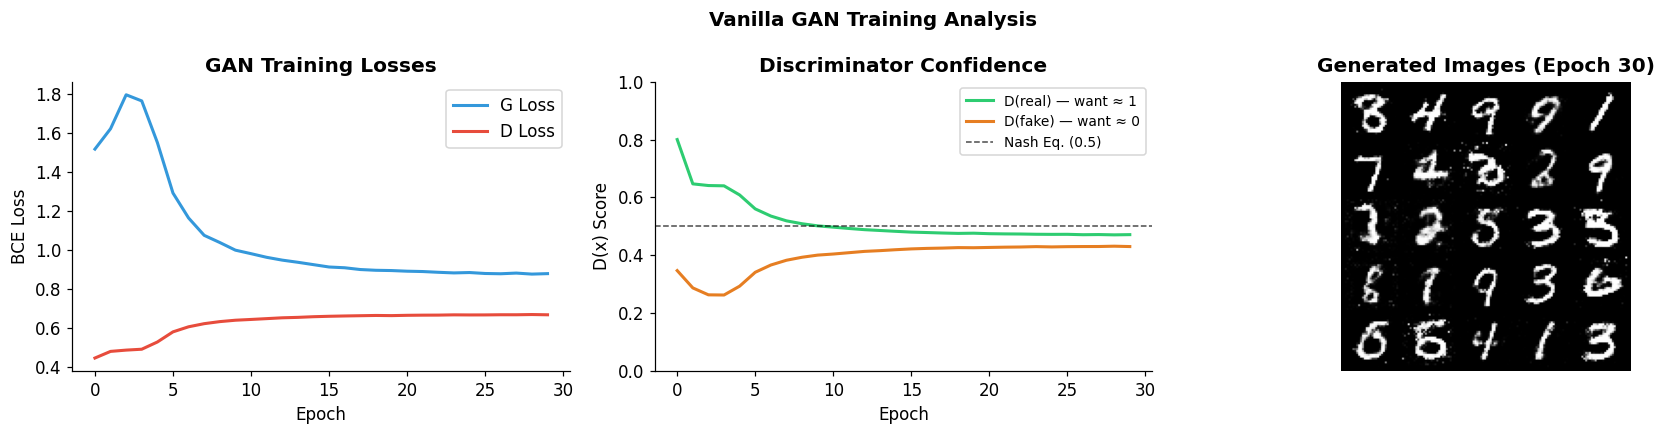

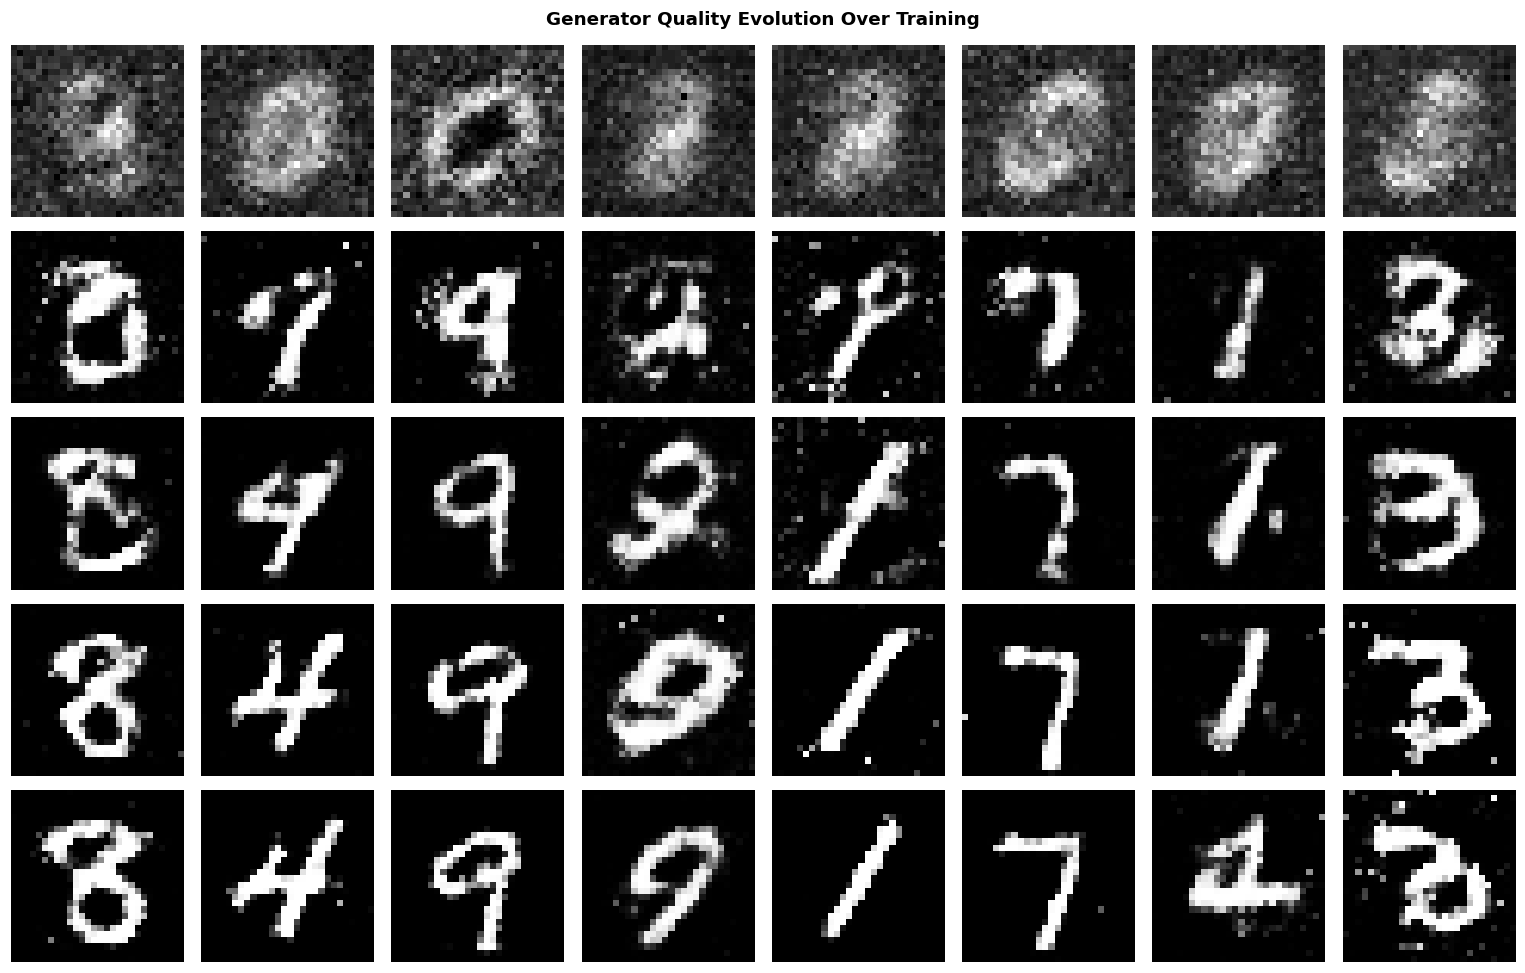

In [16]:
# Visualise GAN Training 
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Generator & Discriminator loss
axes[0].plot(gan_g_losses, color='#3498db', linewidth=2, label='G Loss')
axes[0].plot(gan_d_losses, color='#e74c3c', linewidth=2, label='D Loss')
axes[0].set_title('GAN Training Losses', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend()

# D(real) and D(fake) scores
axes[1].plot(gan_d_real, color='#2ecc71', linewidth=2, label='D(real) — want ≈ 1')
axes[1].plot(gan_d_fake, color='#e67e22', linewidth=2, label='D(fake) — want ≈ 0')
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Nash Eq. (0.5)')
axes[1].set_ylim(0, 1)
axes[1].set_title('Discriminator Confidence', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('D(x) Score')
axes[1].legend(fontsize=9)

# Final generated images
G.eval()
with torch.no_grad():
    final_imgs = G(fixed_noise[:25]).cpu()

grid = make_grid(final_imgs, nrow=5, normalize=True, value_range=(-1,1))
axes[2].imshow(grid.permute(1,2,0), cmap='gray')
axes[2].axis('off')
axes[2].set_title('Generated Images (Epoch 30)', fontweight='bold')

plt.suptitle('Vanilla GAN Training Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Generator evolution snapshots
epochs_shown = sorted(sample_snapshots.keys())
fig, axes = plt.subplots(len(epochs_shown), 8, figsize=(14, len(epochs_shown)*1.8))

for row, ep in enumerate(epochs_shown):
    imgs = sample_snapshots[ep]
    for col in range(8):
        axes[row, col].imshow(imgs[col,0].numpy(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Epoch {ep}', fontsize=10, fontweight='bold')

plt.suptitle('Generator Quality Evolution Over Training', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 8: Deep Convolutional GAN (DCGAN)

**DCGAN** (Radford et al., 2015) replaces fully-connected layers with **convolutional layers**, dramatically improving image quality.

### DCGAN Architecture Guidelines
| Component | Technique | Reason |
|---|---|---|
| Generator | **Transposed convolutions** (upsample) | Learned spatial upsampling |
| Generator | **BatchNorm** on all layers except output | Stabilises training |
| Generator | **ReLU** activations, **Tanh** output | Standard |
| Discriminator | **Strided convolutions** (downsample) | No pooling layers |
| Discriminator | **BatchNorm** on all layers except input | Stabilises training |
| Discriminator | **LeakyReLU** (α=0.2) | Prevents dying neurons |
| Both | **No fully-connected hidden layers** | Pure ConvNet |

### Architecture Flow
```
Generator (z=100 → 1×28×28):
  z(100) → FC(7×7×256) → Reshape → TransposedConv→ BatchNorm → ReLU
         → TransposedConv(14×14×128) → BatchNorm → ReLU
         → TransposedConv(28×28×1)   → Tanh

Discriminator (1×28×28 → real/fake):
  → Conv(14×14×64) → LeakyReLU
  → Conv(7×7×128)  → BatchNorm → LeakyReLU
  → Flatten → FC(1) → Sigmoid
```

In [17]:
# Section 8 — DCGAN for MNIST


class DCGenerator(nn.Module):
    """Convolutional Generator: z → image."""
    def __init__(self, latent_dim=100):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 7 * 7 * 256)
        self.conv_layers = nn.Sequential(
            # 7×7×256 → 14×14×128
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 14×14×128 → 28×28×64
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 28×28×64 → 28×28×1  (same size, refine)
            nn.ConvTranspose2d(64, 1, 3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 256, 7, 7)
        return self.conv_layers(x)


class DCDiscriminator(nn.Module):
    """Convolutional Discriminator: image → P(real)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 1×28×28 → 64×14×14
            nn.Conv2d(1, 64, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 64×14×14 → 128×7×7
            nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128×7×7 → 256×3×3
            nn.Conv2d(128, 256, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


# Init 
LATENT_DIM_DC = 100
DC_G = DCGenerator(latent_dim=LATENT_DIM_DC).to(DEVICE)
DC_D = DCDiscriminator().to(DEVICE)

def dc_weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

DC_G.apply(dc_weights_init)
DC_D.apply(dc_weights_init)

dc_g_optim = optim.Adam(DC_G.parameters(), lr=2e-4, betas=(0.5, 0.999))
dc_d_optim = optim.Adam(DC_D.parameters(), lr=2e-4, betas=(0.5, 0.999))
dc_criterion = nn.BCELoss()

dc_g_p = sum(p.numel() for p in DC_G.parameters())
dc_d_p = sum(p.numel() for p in DC_D.parameters())
print(f' DCGAN')
print(f'   DC Generator:     {dc_g_p:,} parameters')
print(f'   DC Discriminator: {dc_d_p:,} parameters')

 DCGAN
   DC Generator:     1,923,264 parameters
   DC Discriminator: 659,457 parameters


In [18]:
# DCGAN Training 
DCGAN_EPOCHS = 25
dc_g_losses  = []
dc_d_losses  = []
dc_d_real_h  = []
dc_d_fake_h  = []
dc_snapshots = {}
dc_fixed_noise = torch.randn(64, LATENT_DIM_DC).to(DEVICE)



for epoch in range(DCGAN_EPOCHS):
    g_ep = d_ep = dr_ep = df_ep = 0
    n = 0
    DC_G.train(); DC_D.train()

    for real_imgs, _ in train_loader:
        B         = real_imgs.size(0)
        real_imgs = real_imgs.to(DEVICE)
        r_labels  = torch.full((B,1), 0.9).to(DEVICE)   # label smoothing
        f_labels  = torch.zeros(B, 1).to(DEVICE)

        # Train D
        dc_d_optim.zero_grad()
        d_r = DC_D(real_imgs)
        loss_r = dc_criterion(d_r, r_labels)
        z     = torch.randn(B, LATENT_DIM_DC).to(DEVICE)
        fakes = DC_G(z).detach()
        d_f   = DC_D(fakes)
        loss_f = dc_criterion(d_f, f_labels)
        d_loss = (loss_r + loss_f) / 2
        d_loss.backward(); dc_d_optim.step()

        # Train G
        dc_g_optim.zero_grad()
        z     = torch.randn(B, LATENT_DIM_DC).to(DEVICE)
        fakes = DC_G(z)
        g_out = DC_D(fakes)
        g_loss = dc_criterion(g_out, torch.ones(B,1).to(DEVICE))
        g_loss.backward(); dc_g_optim.step()

        g_ep += g_loss.item(); d_ep += d_loss.item()
        dr_ep += d_r.mean().item(); df_ep += d_f.mean().item()
        n += 1

    dc_g_losses.append(g_ep/n); dc_d_losses.append(d_ep/n)
    dc_d_real_h.append(dr_ep/n); dc_d_fake_h.append(df_ep/n)

    if epoch+1 in [1, 5, 10, 15, 25]:
        DC_G.eval()
        with torch.no_grad():
            dc_snapshots[epoch+1] = DC_G(dc_fixed_noise[:16]).cpu()
        DC_G.train()

    if (epoch+1) % 5 == 0:
        print(f'  Epoch {epoch+1:2d}/{DCGAN_EPOCHS} | '
              f'G: {g_ep/n:.4f} | D: {d_ep/n:.4f} | '
              f'D(real): {dr_ep/n:.3f} | D(fake): {df_ep/n:.3f}')



  Epoch  5/25 | G: 2.1381 | D: 0.3491 | D(real): 0.723 | D(fake): 0.176
  Epoch 10/25 | G: 2.4765 | D: 0.3158 | D(real): 0.757 | D(fake): 0.142
  Epoch 15/25 | G: 2.7371 | D: 0.2809 | D(real): 0.787 | D(fake): 0.113
  Epoch 20/25 | G: 2.8839 | D: 0.2828 | D(real): 0.793 | D(fake): 0.107
  Epoch 25/25 | G: 2.9557 | D: 0.2698 | D(real): 0.801 | D(fake): 0.099


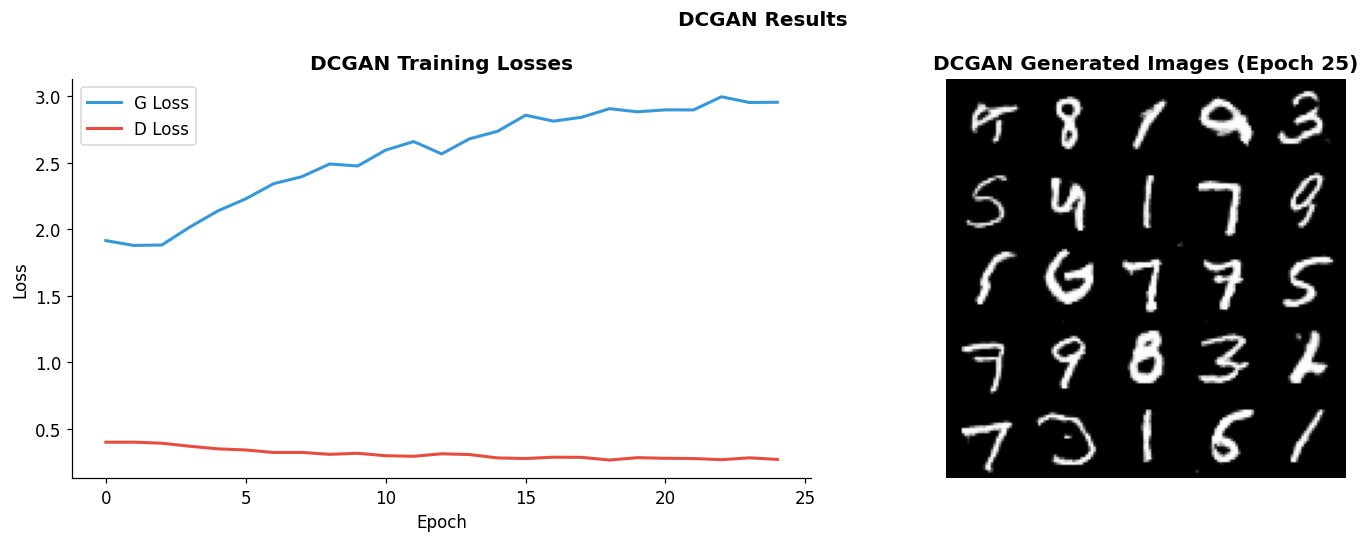

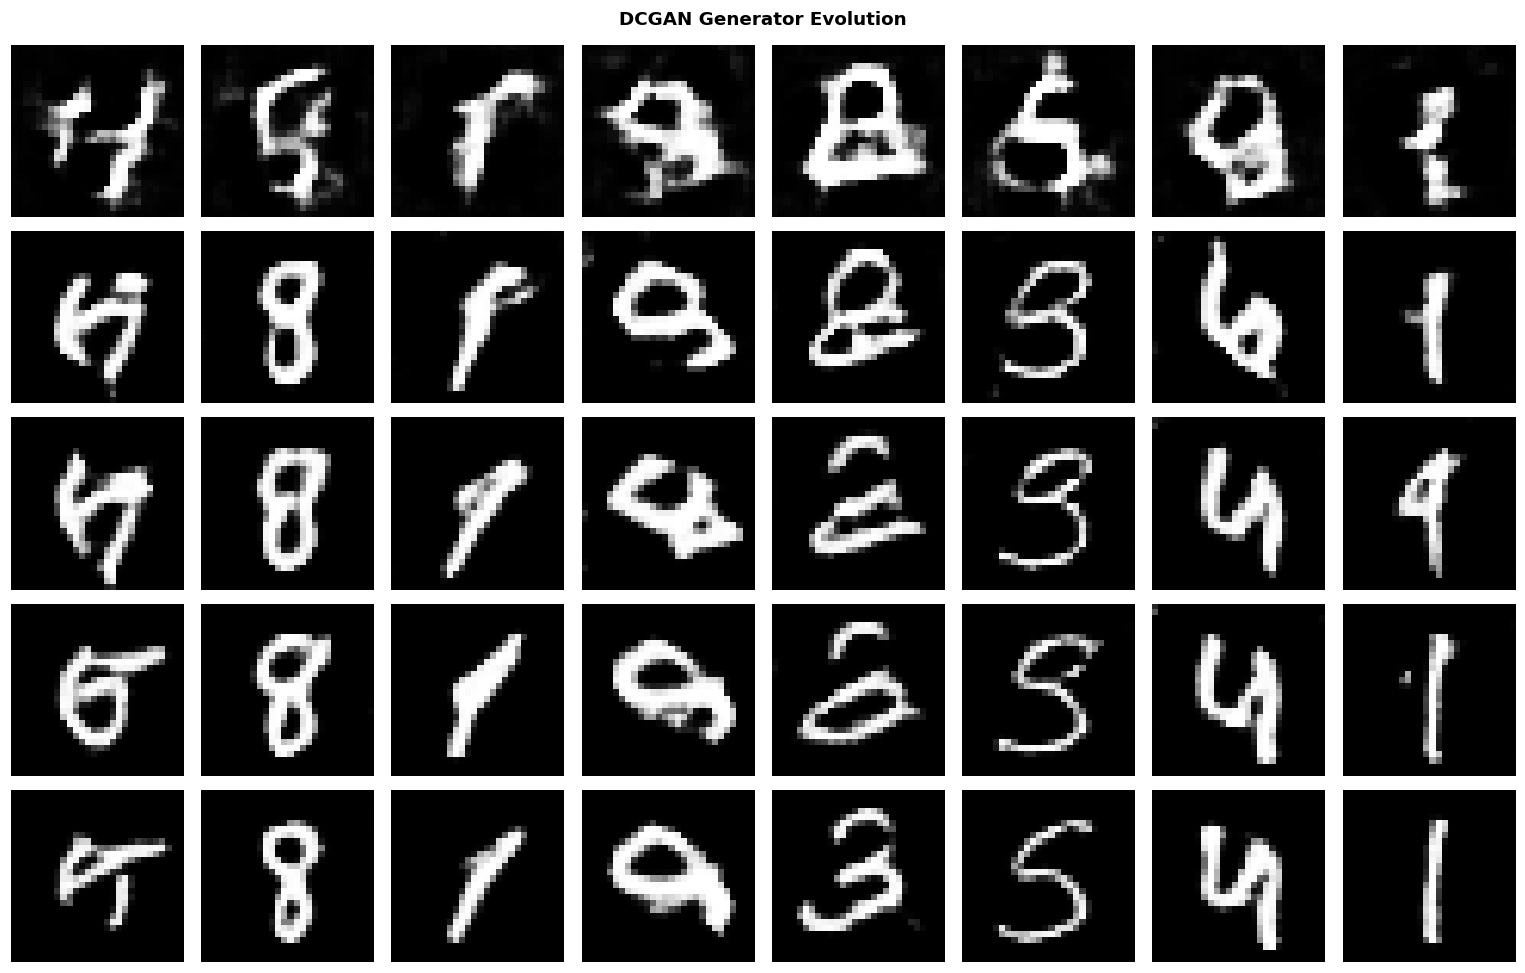

In [19]:
# DCGAN Visual Results
DC_G.eval()
with torch.no_grad():
    dc_final_imgs = DC_G(dc_fixed_noise[:64]).cpu()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Losses
axes[0].plot(dc_g_losses, color='#3498db', linewidth=2, label='G Loss')
axes[0].plot(dc_d_losses, color='#e74c3c', linewidth=2, label='D Loss')
axes[0].set_title('DCGAN Training Losses', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

# Generated grid
grid = make_grid(dc_final_imgs[:25], nrow=5, normalize=True, value_range=(-1,1))
axes[1].imshow(grid.permute(1,2,0).numpy(), cmap='gray')
axes[1].axis('off')
axes[1].set_title('DCGAN Generated Images (Epoch 25)', fontweight='bold')

plt.suptitle('DCGAN Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Snapshot grid
epochs_shown_dc = sorted(dc_snapshots.keys())
fig, axes = plt.subplots(len(epochs_shown_dc), 8, figsize=(14, len(epochs_shown_dc)*1.8))
for row, ep in enumerate(epochs_shown_dc):
    imgs = dc_snapshots[ep]
    for col in range(8):
        axes[row,col].imshow(imgs[col,0].numpy(), cmap='gray')
        axes[row,col].axis('off')
    axes[row,0].set_ylabel(f'Ep {ep}', fontsize=10, fontweight='bold')
plt.suptitle('DCGAN Generator Evolution', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 9: GAN Training Challenges & Solutions

GANs are notoriously difficult to train. Here are the key failure modes and remedies:

### Common Problems
| Problem | Symptoms | Solutions |
|---|---|---|
| **Mode Collapse** | Generator produces only a few outputs; ignores most of data distribution | Minibatch discrimination, Unrolled GAN, WGAN |
| **Training Instability** | Losses oscillate wildly; D or G collapses | Label smoothing, spectral norm, gradient penalty |
| **Vanishing Gradients** | G loss saturates; no gradient signal for G | Non-saturating loss: maximize `log D(G(z))` instead of minimising `log(1-D(G(z)))` |
| **D too strong** | G never improves; D loss → 0 | Slower D updates, gradient clipping, add noise to D inputs |

### WGAN : Wasserstein GAN
Replaces BCE loss with the **Wasserstein distance** (Earth Mover's Distance) — provides stable gradients even when distributions don't overlap:
```
min_G max_D  E[D(x)] - E[D(G(z))]
            subject to: D is 1-Lipschitz (||∇D|| ≤ 1)
```
Enforced via **gradient penalty** (WGAN-GP).

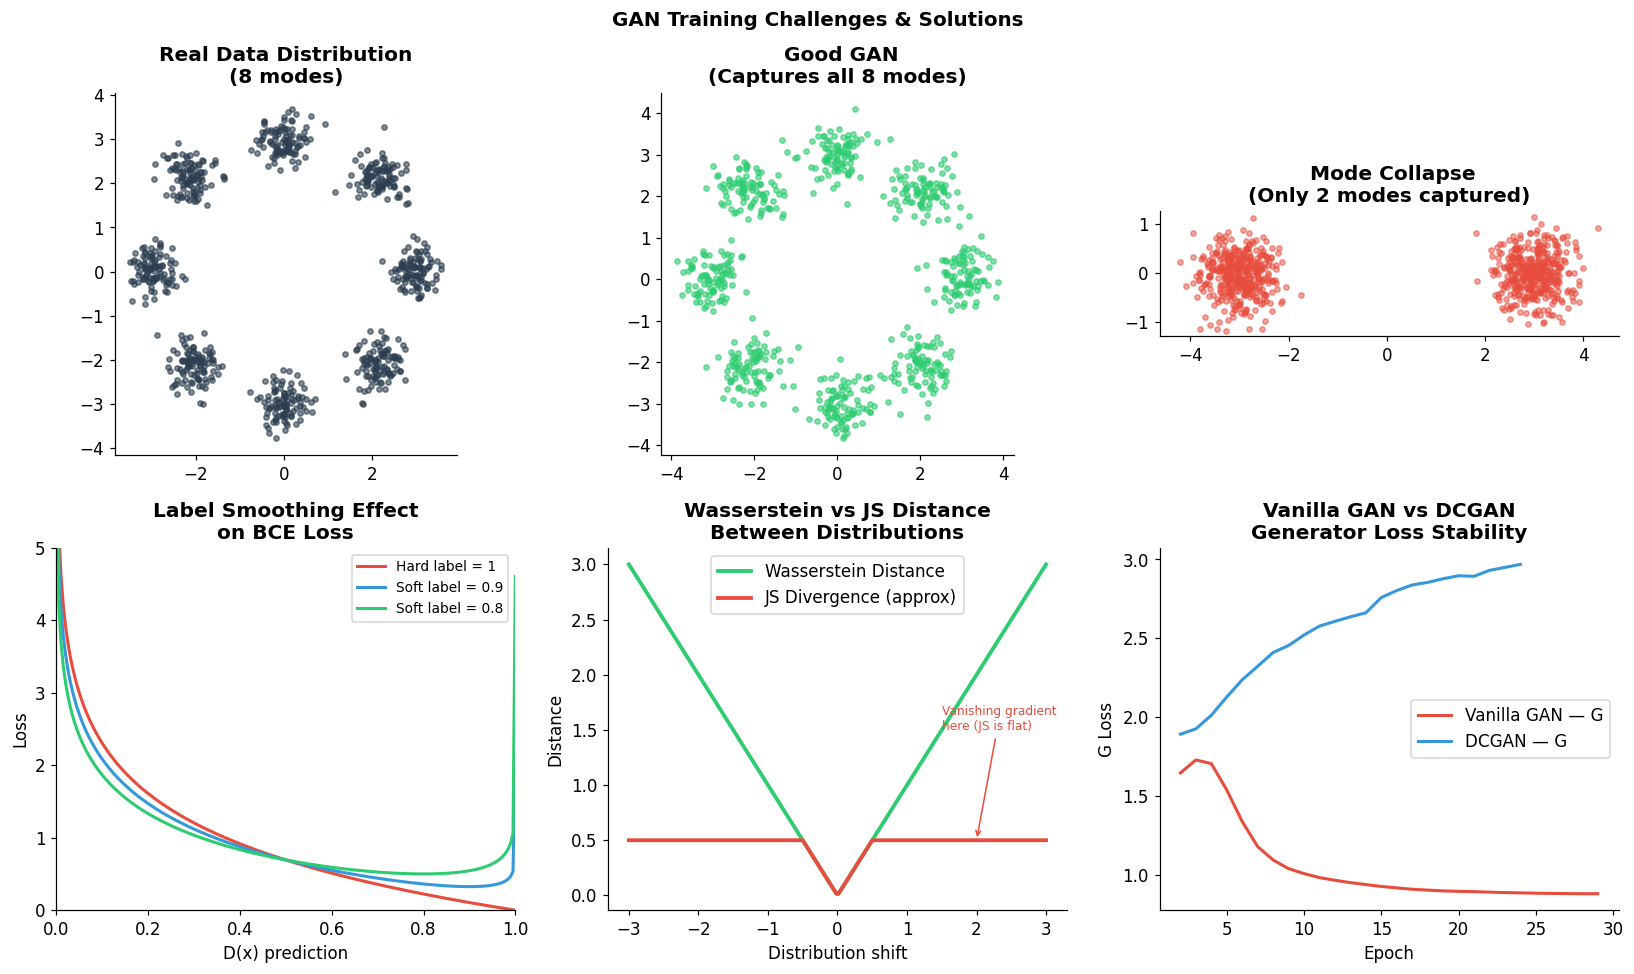

In [20]:
# Section 9 — GAN Failure Modes Visualisation & Tricks

np.random.seed(SEED)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Real data: 8 modes in 2D
angles   = np.linspace(0, 2*np.pi, 9)[:-1]
centers  = np.stack([np.cos(angles)*3, np.sin(angles)*3], axis=1)
real_pts = np.concatenate([np.random.randn(100,2)*0.3 + c for c in centers])

# Normal GAN: captures all modes
good_pts = np.concatenate([np.random.randn(90,2)*0.4 + c for c in centers])

# Mode collapse: only captures 2 modes
collapsed_pts = np.concatenate([
    np.random.randn(400,2)*0.4 + centers[0],
    np.random.randn(400,2)*0.4 + centers[4]
])

axes[0,0].scatter(real_pts[:,0], real_pts[:,1], c='#2c3e50', s=12, alpha=0.6)
axes[0,0].set_title('Real Data Distribution\n(8 modes)', fontweight='bold')
axes[0,0].set_aspect('equal')

axes[0,1].scatter(good_pts[:,0], good_pts[:,1], c='#2ecc71', s=12, alpha=0.6)
axes[0,1].set_title(' Good GAN\n(Captures all 8 modes)', fontweight='bold')
axes[0,1].set_aspect('equal')

axes[0,2].scatter(collapsed_pts[:,0], collapsed_pts[:,1], c='#e74c3c', s=12, alpha=0.5)
axes[0,2].set_title(' Mode Collapse\n(Only 2 modes captured)', fontweight='bold')
axes[0,2].set_aspect('equal')

# Label smoothing effect
x_vals = np.linspace(0, 1, 200)
bce_no_smooth  = -np.log(x_vals + 1e-10)   # standard label = 1
bce_smooth_09  = -(0.9 * np.log(x_vals + 1e-10) + 0.1 * np.log(1 - x_vals + 1e-10))
bce_smooth_08  = -(0.8 * np.log(x_vals + 1e-10) + 0.2 * np.log(1 - x_vals + 1e-10))

axes[1,0].plot(x_vals, bce_no_smooth, color='#e74c3c', linewidth=2, label='Hard label = 1')
axes[1,0].plot(x_vals, bce_smooth_09, color='#3498db', linewidth=2, label='Soft label = 0.9')
axes[1,0].plot(x_vals, bce_smooth_08, color='#2ecc71', linewidth=2, label='Soft label = 0.8')
axes[1,0].set_ylim(0, 5); axes[1,0].set_xlim(0, 1)
axes[1,0].set_title('Label Smoothing Effect\non BCE Loss', fontweight='bold')
axes[1,0].set_xlabel('D(x) prediction'); axes[1,0].set_ylabel('Loss')
axes[1,0].legend(fontsize=9)

# Wasserstein vs JS divergence
shift_vals = np.linspace(-3, 3, 200)
wd   = np.abs(shift_vals)              # Wasserstein: linear, always nonzero
jsd  = np.where(np.abs(shift_vals) < 0.5, np.abs(shift_vals),
                0.5 + np.zeros_like(shift_vals))  # JS: plateaus when no overlap

axes[1,1].plot(shift_vals, wd,  color='#2ecc71', linewidth=2.5, label='Wasserstein Distance')
axes[1,1].plot(shift_vals, jsd, color='#e74c3c', linewidth=2.5, label='JS Divergence (approx)')
axes[1,1].set_title('Wasserstein vs JS Distance\nBetween Distributions', fontweight='bold')
axes[1,1].set_xlabel('Distribution shift'); axes[1,1].set_ylabel('Distance')
axes[1,1].legend()
axes[1,1].annotate('Vanishing gradient\nhere (JS is flat)',
                    xy=(2, 0.5), xytext=(1.5, 1.5),
                    fontsize=8, color='#e74c3c',
                    arrowprops=dict(arrowstyle='->', color='#e74c3c'))

# Comparison: Vanilla vs DCGAN loss quality
axes[1,2].plot(pd.Series(gan_g_losses).rolling(3).mean(),
               color='#e74c3c', linewidth=2, label='Vanilla GAN — G')
axes[1,2].plot(pd.Series(dc_g_losses).rolling(3).mean(),
               color='#3498db', linewidth=2, label='DCGAN — G')
axes[1,2].set_title('Vanilla GAN vs DCGAN\nGenerator Loss Stability', fontweight='bold')
axes[1,2].set_xlabel('Epoch'); axes[1,2].set_ylabel('G Loss')
axes[1,2].legend()

plt.suptitle('GAN Training Challenges & Solutions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 10: Diffusion Models | Theory & Foundations

**Diffusion Models** (Ho et al., "Denoising Diffusion Probabilistic Models", 2020) are now the **state-of-the-art** for image generation, powering Stable Diffusion, DALL·E 2, and Imagen.

### Core Idea
Diffusion models learn to **reverse a gradual noising process**:

```
Forward Process  (fixed, adds Gaussian noise step by step):
  x_0 (clean) → x_1 → x_2 → ... → x_T (pure noise ~ N(0,I))

Reverse Process  (learned, denoises step by step):
  x_T (noise) → x_{T-1} → ... → x_1 → x_0 (clean image)
```

### Forward Process (Noise Schedule)
Each step adds a small amount of Gaussian noise:
```
q(x_t | x_{t-1}) = N(x_t; √(1-β_t)·x_{t-1}, β_t·I)
```
With the **closed-form shortcut** (can jump to any timestep directly):
```
q(x_t | x_0) = N(x_t; √ᾱ_t · x_0, (1-ᾱ_t)·I)
where ᾱ_t = ∏_{s=1}^{t} (1 - β_s)
```

### What the Network Learns
A U-Net `ε_θ(x_t, t)` is trained to **predict the noise ε** that was added:
```
L = E_{x_0, ε, t} [ ||ε - ε_θ(x_t, t)||² ]
```

### Sampling (Reverse Diffusion)
```
x_{t-1} = (1/√α_t) · (x_t - β_t/√(1-ᾱ_t) · ε_θ(x_t, t)) + σ_t · z
where z ~ N(0,I)
```

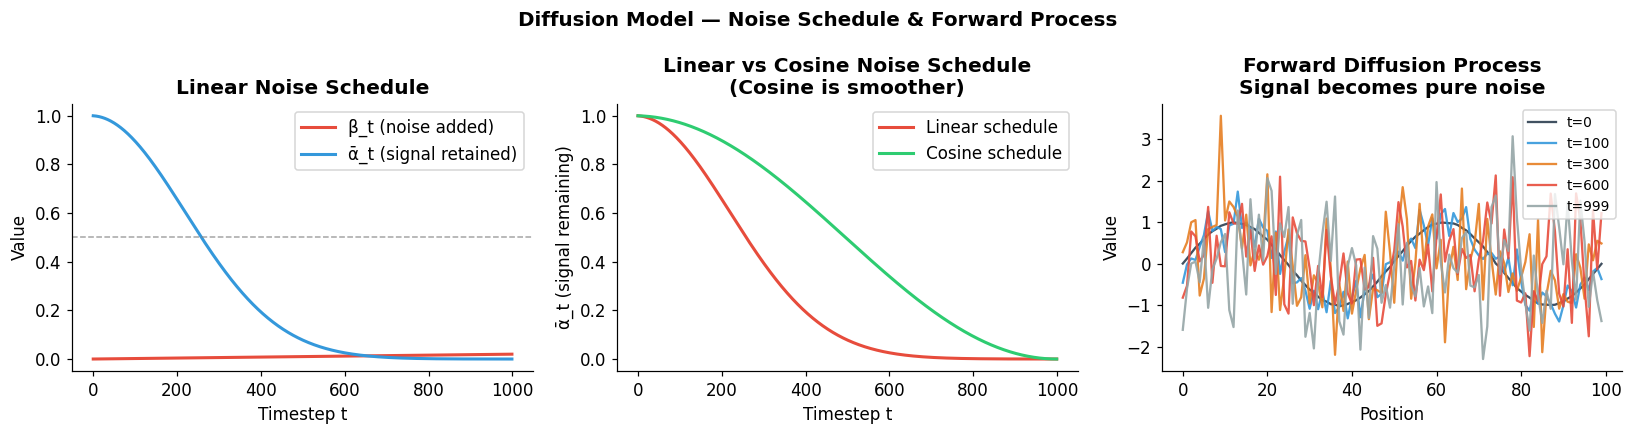

In [22]:
# Section 10 — Diffusion Process Visualisation


#  Visualise the noise schedule 
T       = 1000      # total diffusion timesteps
beta_start = 0.0001
beta_end   = 0.02

# Linear noise schedule
betas   = torch.linspace(beta_start, beta_end, T)
alphas  = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)   # ᾱ_t

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

t_vals = np.arange(T)
axes[0].plot(t_vals, betas.numpy(),      color='#e74c3c', linewidth=2, label='β_t (noise added)')
axes[0].plot(t_vals, alpha_bar.numpy(),  color='#3498db', linewidth=2, label='ᾱ_t (signal retained)')
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_title('Linear Noise Schedule', fontweight='bold')
axes[0].set_xlabel('Timestep t'); axes[0].set_ylabel('Value')
axes[0].legend()

# Cosine vs Linear schedule
# Cosine schedule (Nichol & Dhariwal, 2021) — better for images
s = 0.008
steps = torch.arange(T+1, dtype=torch.float32)
f_t   = torch.cos((steps/T + s) / (1 + s) * np.pi/2) ** 2
alpha_bar_cos = f_t / f_t[0]
alpha_bar_cos = alpha_bar_cos[1:]

axes[1].plot(t_vals, alpha_bar.numpy(),     color='#e74c3c', linewidth=2, label='Linear schedule')
axes[1].plot(t_vals, alpha_bar_cos.numpy(), color='#2ecc71', linewidth=2, label='Cosine schedule')
axes[1].set_title('Linear vs Cosine Noise Schedule\n(Cosine is smoother)', fontweight='bold')
axes[1].set_xlabel('Timestep t'); axes[1].set_ylabel('ᾱ_t (signal remaining)')
axes[1].legend()

# Forward noising on a simple signal
np.random.seed(SEED)
x_0   = np.sin(np.linspace(0, 4*np.pi, 100))   # clean signal
t_show = [0, 100, 300, 600, 999]
colors_t = ['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#95a5a6']

for t_idx, color in zip(t_show, colors_t):
    ab   = alpha_bar[t_idx].item()
    x_t  = np.sqrt(ab) * x_0 + np.sqrt(1-ab) * np.random.randn(100)
    axes[2].plot(x_t, color=color, linewidth=1.5, alpha=0.9, label=f't={t_idx}')

axes[2].set_title('Forward Diffusion Process\nSignal becomes pure noise', fontweight='bold')
axes[2].set_xlabel('Position'); axes[2].set_ylabel('Value')
axes[2].legend(fontsize=9)

plt.suptitle('Diffusion Model — Noise Schedule & Forward Process', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

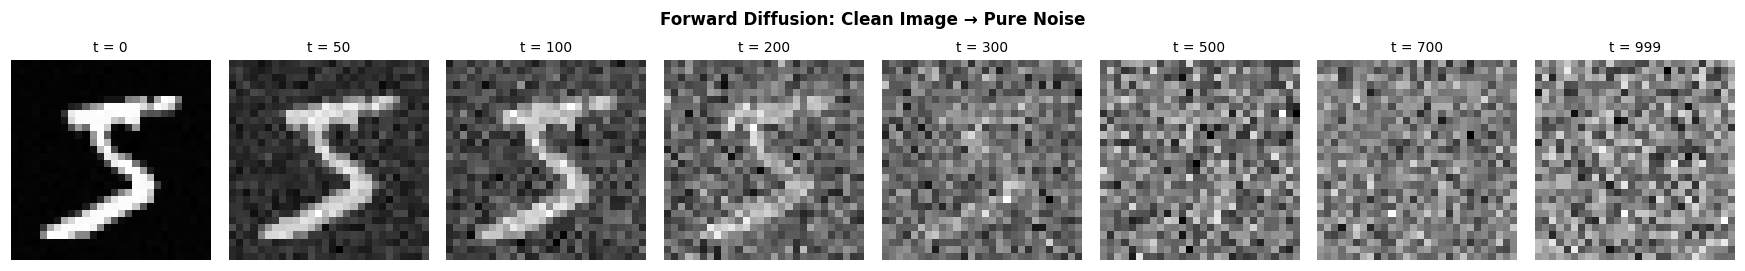

 The model learns to REVERSE this process: noise → clean image
   At each step it predicts: what noise was added at this timestep?


In [23]:
# forward Diffusion on MNIST Images
def forward_diffuse(x0, t, alpha_bars):
    """Closed-form forward diffusion: x_t = √ᾱ_t·x₀ + √(1-ᾱ_t)·ε"""
    ab  = alpha_bars[t].view(-1, 1, 1, 1).to(x0.device)
    eps = torch.randn_like(x0)
    x_t = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * eps
    return x_t, eps

# Show forward process on one MNIST image
sample_img, _ = vae_train_ds[0]
sample_img    = sample_img.unsqueeze(0) * 2 - 1   # [0,1] → [-1,1]

T_steps_show = [0, 50, 100, 200, 300, 500, 700, 999]

fig, axes = plt.subplots(1, len(T_steps_show), figsize=(16, 2.5))

for i, t_step in enumerate(T_steps_show):
    t_tensor = torch.tensor([t_step])
    x_t, _   = forward_diffuse(sample_img, t_tensor, alpha_bar)
    axes[i].imshow(x_t[0,0].numpy(), cmap='gray')
    axes[i].set_title(f't = {t_step}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Forward Diffusion: Clean Image → Pure Noise', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(' The model learns to REVERSE this process: noise → clean image')
print('   At each step it predicts: what noise was added at this timestep?')

---
## Section 11: Denoising Diffusion | Implementation

We implement a lightweight **DDPM** on MNIST with:
- A **small U-Net** with time embeddings (the noise predictor `ε_θ`)
- **Sinusoidal time embeddings** to condition on timestep
- **DDPM sampling** loop (reverse diffusion)

### U-Net Architecture (simplified)
```
x_t + time_emb
      ↓
 [Down-block 1]  ── skip ──┐
      ↓                     │
 [Down-block 2]  ── skip ──┤
      ↓                     │
  [Bottleneck]              │
      ↓                     │
 [Up-block 1] ← cat ────────┤
      ↓                     │
 [Up-block 2] ← cat ────────┘
      ↓
 predicted noise ε_θ(x_t, t)
```

In [24]:
# Section 11 — Simplified Diffusion Model (DDPM) on MNIST

class SinusoidalTimeEmbedding(nn.Module):
    """
    Encodes timestep t as a sinusoidal positional embedding
    (same idea as Transformer positional encodings).
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device    = t.device
        half_dim  = self.dim // 2
        emb       = np.log(10000) / (half_dim - 1)
        emb       = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb       = t.float()[:, None] * emb[None, :]
        emb       = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp  = nn.Linear(time_dim, out_ch)
        self.skip_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_mlp(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip_conv(x)


class SmallUNet(nn.Module):
    """
    Predicts noise ε given noisy image x_t and timestep t.
    Input:  x_t (B×1×28×28) + t (B,)
    Output: predicted noise (B×1×28×28)
    """
    def __init__(self, in_channels=1, base_ch=32, time_dim=128):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim)
        )

        # Encoder
        self.enc1 = ResBlock(in_channels, base_ch,     time_dim)
        self.enc2 = ResBlock(base_ch,     base_ch*2,   time_dim)
        self.enc3 = ResBlock(base_ch*2,   base_ch*4,   time_dim)

        self.down1 = nn.Conv2d(base_ch,   base_ch,   3, stride=2, padding=1)
        self.down2 = nn.Conv2d(base_ch*2, base_ch*2, 3, stride=2, padding=1)

        # Bottleneck
        self.mid = ResBlock(base_ch*4, base_ch*4, time_dim)

        # Decoder
        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*2, 2, stride=2)
        self.dec2 = ResBlock(base_ch*4,   base_ch*2, time_dim)
        self.up1  = nn.ConvTranspose2d(base_ch*2, base_ch, 2, stride=2)
        self.dec1 = ResBlock(base_ch*2,   base_ch,   time_dim)

        self.out_conv = nn.Conv2d(base_ch, in_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)

        # Encode
        e1 = self.enc1(x,  t_emb)             # B×32×28×28
        e2 = self.enc2(self.down1(e1), t_emb)  # B×64×14×14
        e3 = self.enc3(self.down2(e2), t_emb)  # B×128×7×7

        # Bottleneck
        m  = self.mid(e3, t_emb)               # B×128×7×7

        # Decode (with skip connections)
        d2 = self.dec2(torch.cat([self.up2(m),  e2], dim=1), t_emb)  # B×64×14×14
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb)  # B×32×28×28

        return self.out_conv(d1)


unet = SmallUNet(in_channels=1, base_ch=32, time_dim=128).to(DEVICE)
total_unet = sum(p.numel() for p in unet.parameters())
print(f' U-Net Noise Predictor: {total_unet:,} parameters')

# Quick shape check
dummy_x = torch.randn(2, 1, 28, 28).to(DEVICE)
dummy_t = torch.randint(0, T, (2,)).to(DEVICE)
out = unet(dummy_x, dummy_t)
print(f'   Input shape:  {dummy_x.shape}')
print(f'   Output shape: {out.shape}   (same as input)')

 U-Net Noise Predictor: 953,571 parameters
   Input shape:  torch.Size([2, 1, 28, 28])
   Output shape: torch.Size([2, 1, 28, 28])   (same as input)


In [25]:
diff_optim = optim.Adam(unet.parameters(), lr=2e-4)
diff_scheduler = optim.lr_scheduler.CosineAnnealingLR(diff_optim, T_max=20)

T_DIFF       = 1000
DIFF_EPOCHS  = 20    # train for 20 epochs

# Pre-compute noise schedule tensors
betas_d      = torch.linspace(1e-4, 0.02, T_DIFF).to(DEVICE)
alphas_d     = 1.0 - betas_d
alpha_bar_d  = torch.cumprod(alphas_d, dim=0)

diff_losses  = []


print(f'   Timesteps: {T_DIFF} | Epochs: {DIFF_EPOCHS}')


for epoch in range(DIFF_EPOCHS):
    unet.train()
    epoch_loss = 0
    n_b = 0

    for imgs, _ in vae_train_loader:    # [0,1] range
        imgs  = (imgs * 2 - 1).to(DEVICE)   # → [-1, 1]
        B     = imgs.size(0)

        # Random timestep for each sample in the batch
        t     = torch.randint(0, T_DIFF, (B,), device=DEVICE)

        # Sample noise
        eps   = torch.randn_like(imgs)

        # Forward diffusion: x_t = √ᾱ_t·x₀ + √(1-ᾱ_t)·ε
        ab    = alpha_bar_d[t].view(B, 1, 1, 1)
        x_t   = torch.sqrt(ab) * imgs + torch.sqrt(1 - ab) * eps

        # Predict noise — the entire learning objective!
        eps_pred = unet(x_t, t)

        # Simple MSE loss on noise prediction
        loss = F.mse_loss(eps_pred, eps)

        diff_optim.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        diff_optim.step()

        epoch_loss += loss.item()
        n_b += 1

    diff_scheduler.step()
    avg = epoch_loss / n_b
    diff_losses.append(avg)
    if (epoch+1) % 5 == 0:
        print(f'  Epoch {epoch+1:2d}/{DIFF_EPOCHS}  MSE Loss: {avg:.5f}')


   Timesteps: 1000 | Epochs: 20
  Epoch  5/20  MSE Loss: 0.02939
  Epoch 10/20  MSE Loss: 0.02615
  Epoch 15/20  MSE Loss: 0.02493
  Epoch 20/20  MSE Loss: 0.02460


In [26]:
# DDPM Sampling (Reverse Diffusion)
@torch.no_grad()
def ddpm_sample(unet, n_samples, img_size=(1,28,28),
                T=1000, betas=None, alpha_bar=None, device='cpu',
                return_trajectory=False):
    """
    Sample from the diffusion model by reversing the forward process.
    Starting from x_T ~ N(0,I), iteratively denoise.
    """
    alphas      = 1.0 - betas
    alpha_bar_prev = torch.cat([torch.tensor([1.0]).to(device), alpha_bar[:-1]])
    sqrt_recip  = torch.sqrt(1.0 / alphas)
    sqrt_1m_ab  = torch.sqrt(1.0 - alpha_bar)
    # Posterior variance
    posterior_var = betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)

    unet.eval()
    x = torch.randn(n_samples, *img_size).to(device)   # start from pure noise

    trajectory = [x.clone().cpu()] if return_trajectory else None

    for t_idx in reversed(range(T)):
        t_batch = torch.full((n_samples,), t_idx, dtype=torch.long, device=device)
        eps_pred = unet(x, t_batch)

        # Compute x_{t-1} mean
        coef  = betas[t_idx] / sqrt_1m_ab[t_idx]
        x_mean = sqrt_recip[t_idx] * (x - coef * eps_pred)

        if t_idx > 0:
            noise = torch.randn_like(x)
            x = x_mean + torch.sqrt(posterior_var[t_idx]) * noise
        else:
            x = x_mean   # final step: no noise

        if return_trajectory and t_idx % 100 == 0:
            trajectory.append(x.clone().cpu())

    return x.cpu(), trajectory



generated_diff, traj = ddpm_sample(
    unet, n_samples=64,
    T=T_DIFF, betas=betas_d, alpha_bar=alpha_bar_d,
    device=DEVICE, return_trajectory=True
)
print(f' Generated {len(generated_diff)} samples!')

 Generated 64 samples!


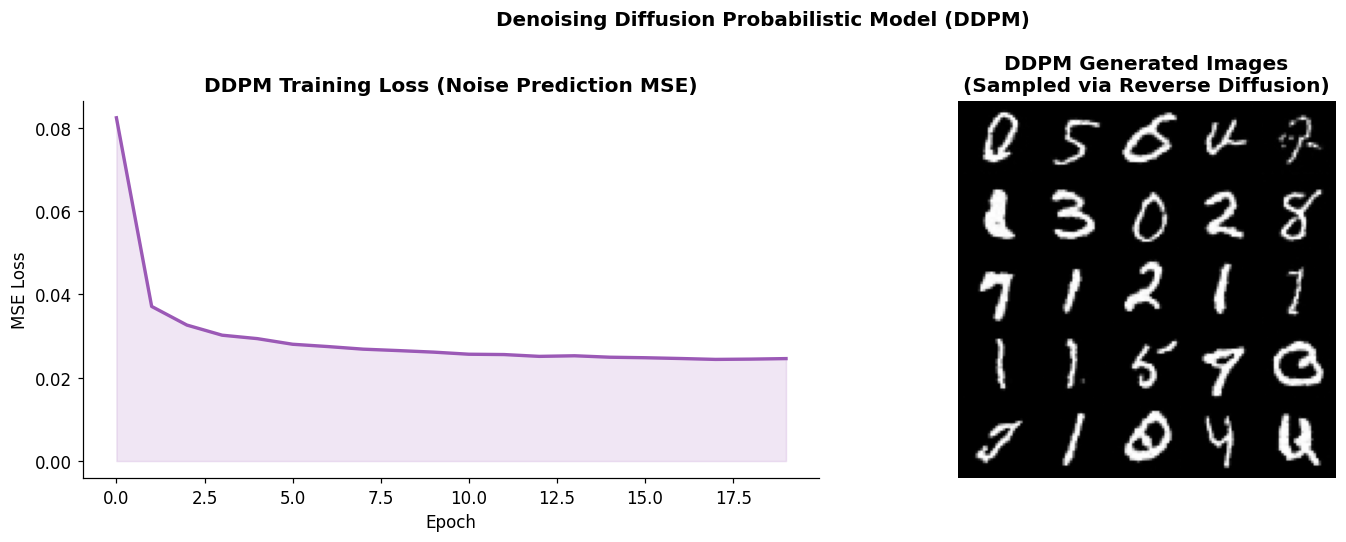

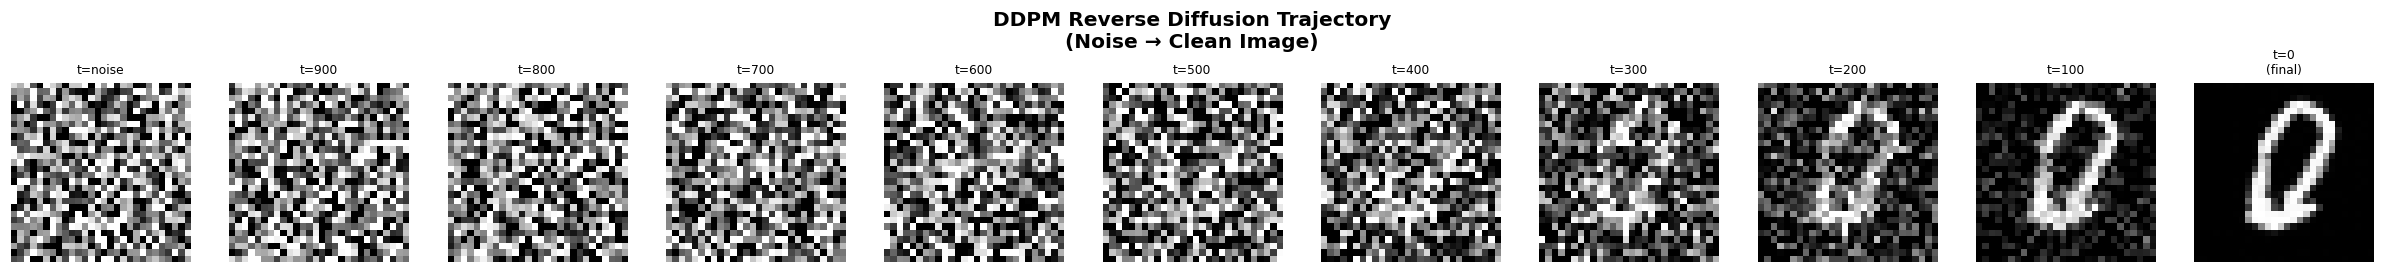

In [27]:
# Visualise DDPM Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
axes[0].plot(diff_losses, color='#9b59b6', linewidth=2.2)
axes[0].fill_between(range(len(diff_losses)), diff_losses, alpha=0.15, color='#9b59b6')
axes[0].set_title('DDPM Training Loss (Noise Prediction MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')

# Generated samples
gen_norm = (generated_diff.clamp(-1, 1) + 1) / 2   # [-1,1] → [0,1]
grid = make_grid(gen_norm[:25], nrow=5, normalize=False)
axes[1].imshow(grid.permute(1,2,0).numpy(), cmap='gray')
axes[1].axis('off')
axes[1].set_title('DDPM Generated Images\n(Sampled via Reverse Diffusion)', fontweight='bold')

plt.suptitle('Denoising Diffusion Probabilistic Model (DDPM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#  Denoising trajectory
if traj:
    n_steps_shown = len(traj)
    fig, axes = plt.subplots(1, n_steps_shown, figsize=(2*n_steps_shown, 2.5))
    t_labels  = list(reversed(range(0, T_DIFF+1, 100)))

    for i, (snap, lbl) in enumerate(zip(traj, t_labels[:n_steps_shown])):
        img_show = (snap[0, 0].clamp(-1,1) + 1) / 2
        axes[i].imshow(img_show.numpy(), cmap='gray')
        axes[i].set_title(f't={lbl}', fontsize=8)
        axes[i].axis('off')

    axes[0].set_title(f't=noise', fontsize=8)
    axes[-1].set_title(f't=0\n(final)', fontsize=8)
    plt.suptitle('DDPM Reverse Diffusion Trajectory\n(Noise → Clean Image)', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Section 12: 🚀 Mini Project | Generative Model Comparison

### Objective
Build a **comprehensive comparison dashboard** across all three generative frameworks:
- **VAE** — structured latent space, smooth interpolation
- **GAN (DCGAN)** — sharp, realistic outputs
- **Diffusion (DDPM)** — highest quality, slowest sampling

### Metrics
| Metric | Description |
|---|---|
| **FID** (Fréchet Inception Distance) | Measures distribution similarity — lower is better |
| **Sharpness** | Mean gradient magnitude of generated images |
| **Diversity** | Std dev of pixel values across samples |
| **Inference speed** | Images generated per second |

In [28]:
# Section 12 — Side-by-Side Comparison Dashboard

import time

# Generate images from all 3 models
N_COMPARE = 64

# VAE
vae_model.eval()
t0 = time.time()
with torch.no_grad():
    z_vae     = torch.randn(N_COMPARE, LATENT_DIM_VAE).to(DEVICE)
    imgs_vae  = vae_model.decode(z_vae).cpu()
vae_time = time.time() - t0

# DCGAN
DC_G.eval()
t0 = time.time()
with torch.no_grad():
    z_dc     = torch.randn(N_COMPARE, LATENT_DIM_DC).to(DEVICE)
    imgs_dc  = DC_G(z_dc).cpu()
    imgs_dc  = (imgs_dc + 1) / 2   # [-1,1] → [0,1]
dcgan_time = time.time() - t0

# DDPM (already generated above)
imgs_diff = gen_norm[:N_COMPARE]

print(f'  Generation Speed ({N_COMPARE} images):')
print(f'   VAE   : {vae_time*1000:.1f}ms  ({N_COMPARE/vae_time:.0f} img/s)')
print(f'   DCGAN : {dcgan_time*1000:.1f}ms  ({N_COMPARE/dcgan_time:.0f} img/s)')
print(f'   DDPM  : ~{T_DIFF} reverse steps (much slower — quality trade-off)')

  Generation Speed (64 images):
   VAE   : 1.6ms  (40494 img/s)
   DCGAN : 3.4ms  (19088 img/s)
   DDPM  : ~1000 reverse steps (much slower — quality trade-off)


In [29]:
#  Compute Image Quality Metrics 
def image_sharpness(imgs_tensor):
    """Mean gradient magnitude — higher = sharper edges."""
    imgs_np = imgs_tensor.numpy()
    grads   = np.abs(np.diff(imgs_np, axis=-1)).mean() + \
              np.abs(np.diff(imgs_np, axis=-2)).mean()
    return grads

def image_diversity(imgs_tensor):
    """Std dev across samples — higher = more diverse."""
    return imgs_tensor.std(dim=0).mean().item()

def pixel_range(imgs_tensor):
    """Average pixel intensity range."""
    return (imgs_tensor.max() - imgs_tensor.min()).item()

def mode_score_proxy(imgs_tensor, n_bins=20):
    """Simple proxy: variance of mean pixel histograms."""
    means = imgs_tensor.mean(dim=(1,2,3)).numpy()
    return np.std(means)

models_compare = {
    'VAE':   imgs_vae,
    'DCGAN': imgs_dc,
    'DDPM':  imgs_diff
}

metrics_compare = {}
for name, imgs in models_compare.items():
    metrics_compare[name] = {
        'Sharpness':  round(float(image_sharpness(imgs)), 4),
        'Diversity':  round(float(image_diversity(imgs)), 4),
        'Pixel Range': round(float(pixel_range(imgs)),   4),
        'Mode Spread': round(float(mode_score_proxy(imgs)), 4),
        'Speed':       'Fast' if name != 'DDPM' else 'Slow',
        'Latent Space':'Structured' if name == 'VAE' else 'Implicit'
    }

metrics_df = pd.DataFrame(metrics_compare).T

print(metrics_df.to_string())

      Sharpness Diversity Pixel Range Mode Spread Speed Latent Space
VAE      0.0959    0.1253      0.9832      0.0271  Fast   Structured
DCGAN    0.1272    0.1755         1.0      0.0362  Fast     Implicit
DDPM     0.1295     0.177         1.0      0.0448  Slow     Implicit


---
## 🎉 Congratulations | You have Completed the Generative AI Handbook!

### What You have Mastered

| Section | Concepts & Skills |
|---|---|
| 1. Introduction | Generative vs discriminative, applications, model taxonomy |
| 2. Foundations | Latent spaces, KL divergence, reparameterisation trick |
| 3. Autoencoders | Encoder-decoder, bottleneck, reconstruction loss, limitations |
| 4. VAE | ELBO, KL regularisation, reparameterisation, β-VAE |
| 5. VAE Generation | Sampling, latent manifold, interpolation, digit traversal |
| 6. GAN Theory | Minimax game, training algorithm, GAN history |
| 7. Vanilla GAN | BCE loss, Generator + Discriminator, label smoothing |
| 8. DCGAN | Transposed convolutions, BatchNorm, strided conv, spectral norm |
| 9. GAN Challenges | Mode collapse, Wasserstein distance, training tricks |
| 10. Diffusion Theory | Forward process, noise schedule, DDPM objective |
| 11. DDPM | U-Net + time embeddings, noise prediction, reverse sampling |
| 12. Mini Project | Full comparison: VAE vs DCGAN vs DDPM, metrics, report |

### 📚 Recommended Next Steps
- **Conditional GAN (cGAN)** : control what class to generate
- **StyleGAN2/3** : state-of-the-art face generation
- **Latent Diffusion Models (LDM)** : Stable Diffusion's backbone
- **DDIM** : deterministic, 10-50x faster diffusion sampling
- **Score-Based Models** : SDEs view of diffusion
- **Flow Matching** : newest paradigm, replacing diffusion
- **DiT** : Diffusion Transformers (SORA's architecture)

### 🔗 Useful Resources
- [Lilian Weng's GAN Survey](https://lilianweng.github.io/posts/2017-08-20-gan/)
- [What are Diffusion Models? (Lilian Weng)](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/)
- [The Annotated Diffusion Model (HuggingFace)](https://huggingface.co/blog/annotated-diffusion)
- [Original DDPM Paper](https://arxiv.org/abs/2006.11239)
- [Original GAN Paper](https://arxiv.org/abs/1406.2661)
- [Original VAE Paper](https://arxiv.org/abs/1312.6114)

